device: cpu

1. Single 128

2. Single 256

3. Independent 128 × 2

4. Joint 128 × 2 / independent init

5. Joint 128 × 2 / noise = 0.0

5. Joint 128 × 2 / noise = 1e-05

5. Joint 128 × 2 / noise = 0.0001

5. Joint 128 × 2 / noise = 0.001

5. Joint 128 × 2 / noise = 0.01

5. Joint 128 × 2 / noise = 0.1


FINAL RESULTS
Single 128 final loss: 2.77734250e-01
Single 256 final loss: 2.29056068e-02
Independent 128×2 ensemble loss: 2.07410499e-01
Joint 128×2 independent-init loss: 2.43291520e-02

Noise experiments
----------------------------------------
noise=0        loss=2.8965e-01 param_cos=1.000000 func_cos=1.000000 func_dist=0.000000
noise=1e-05    loss=4.3015e-02 param_cos=0.702919 func_cos=-0.982295 func_dist=1.991124
noise=0.0001   loss=5.3131e-02 param_cos=0.692017 func_cos=-0.976288 func_dist=1.986817
noise=0.001    loss=4.6195e-02 param_cos=0.671057 func_cos=-0.975063 func_dist=1.989749
noise=0.01     loss=3.7099e-02 param_cos=0.603345 func_cos=-0.977255 func_dist=1.990869
noise=0.

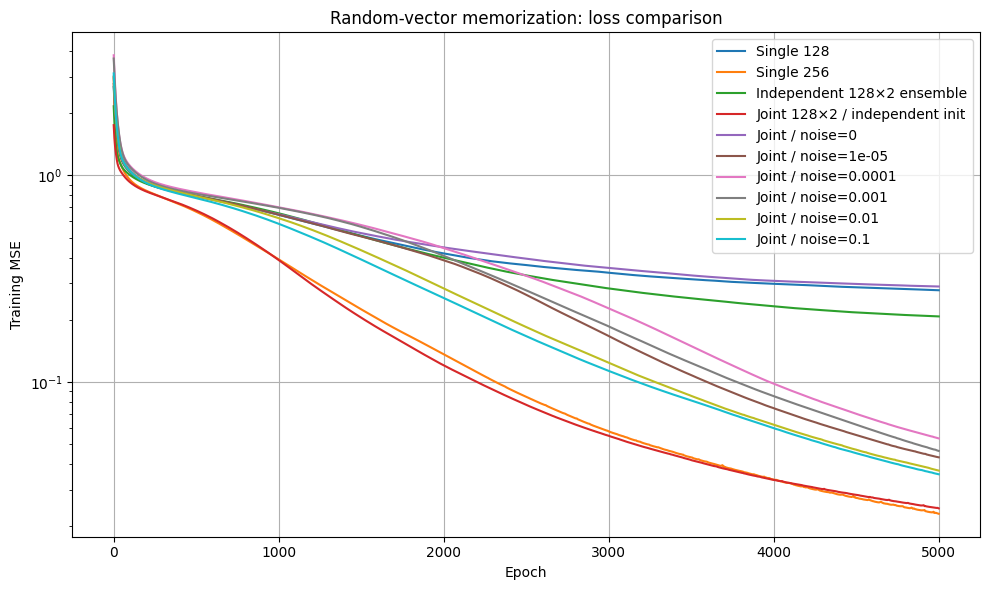

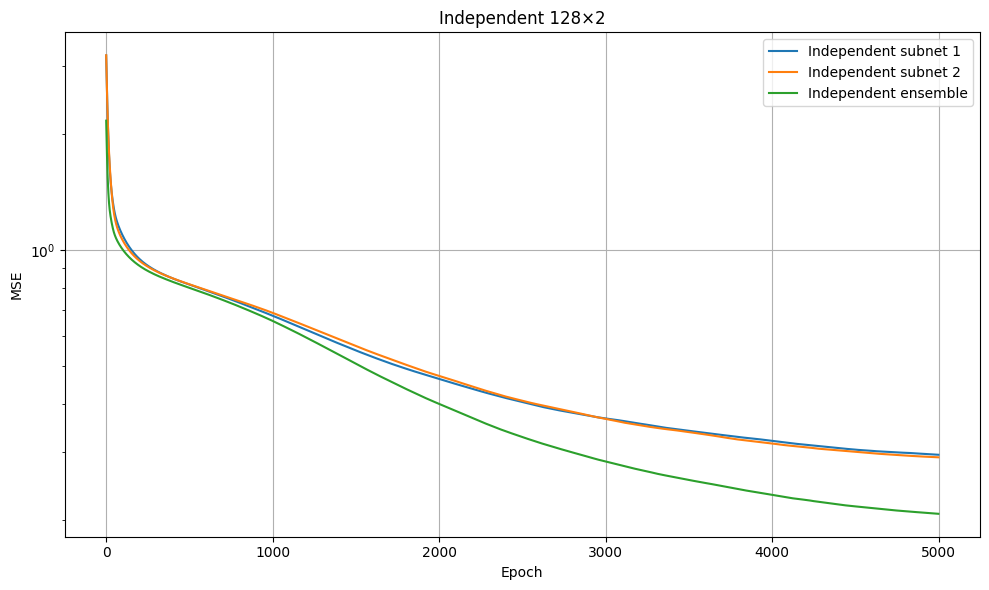

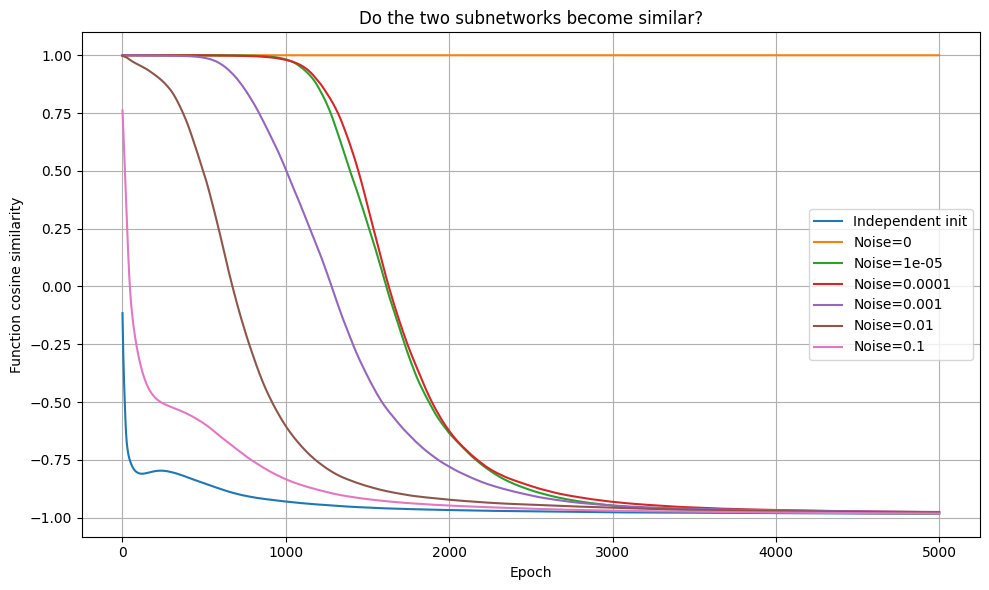

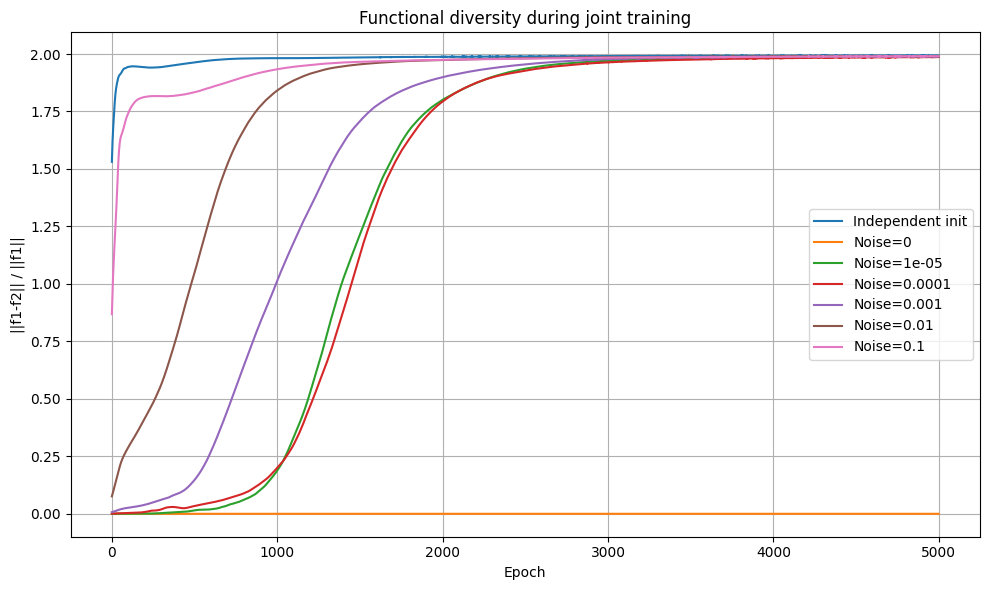

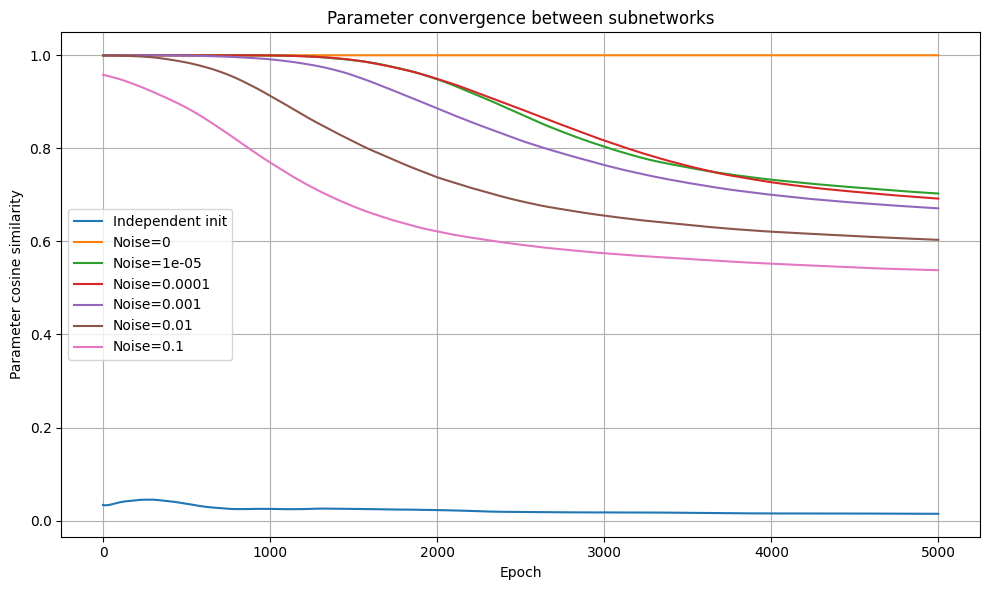

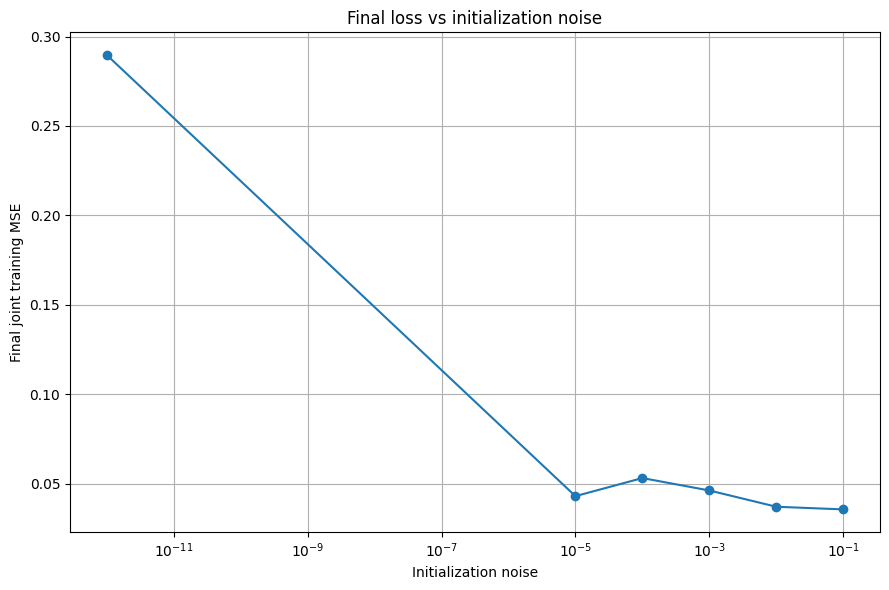

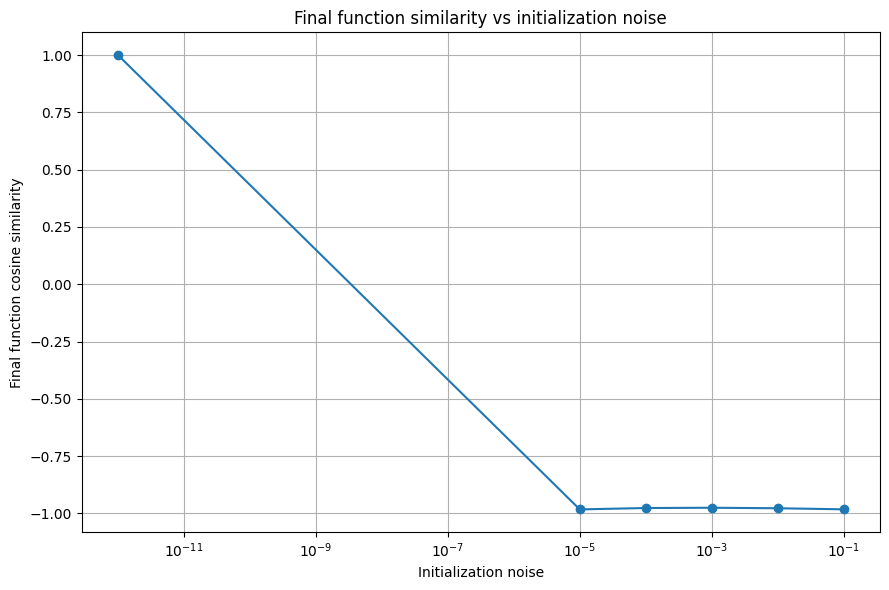

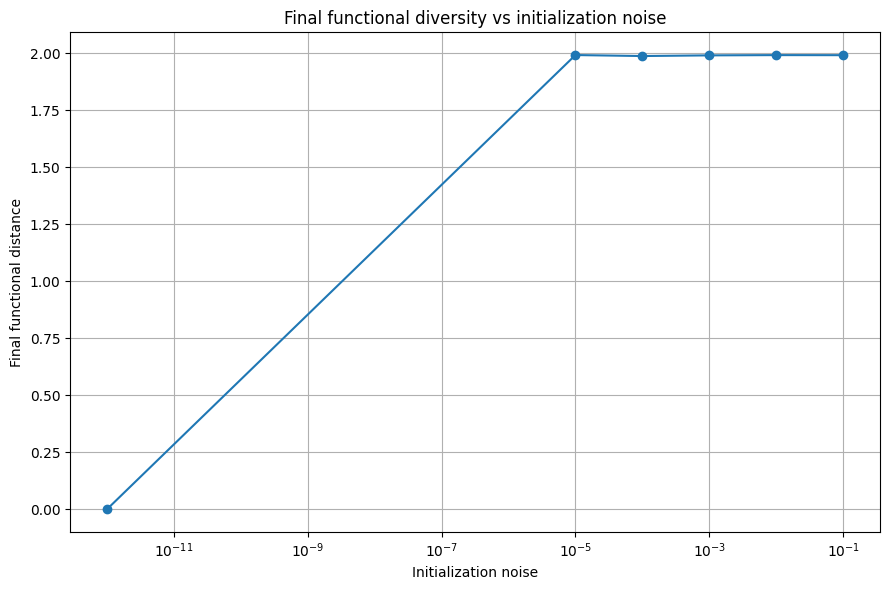

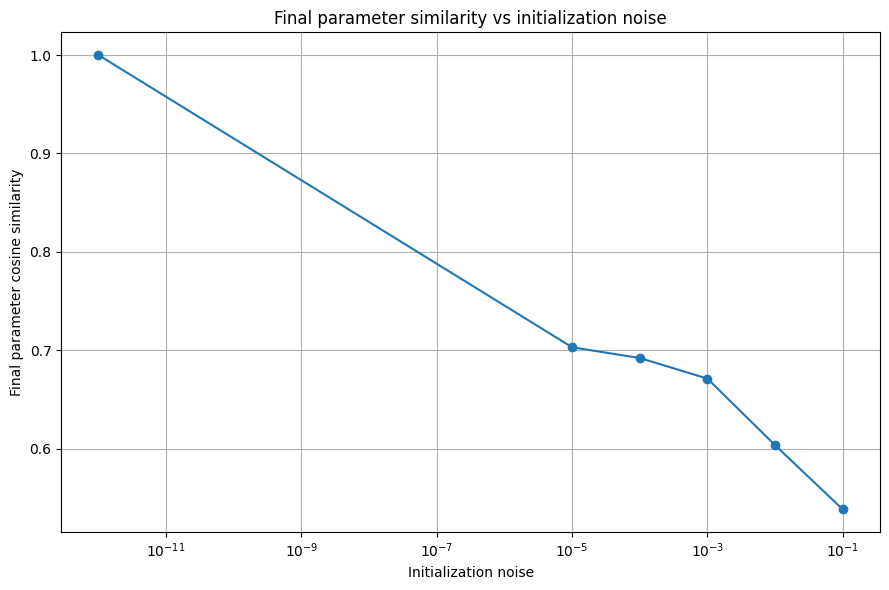

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ============================================================
# 0. Configuration
# ============================================================

SEED = 42

N = 512
INPUT_DIM = 10
OUTPUT_DIM = 10

HIDDEN_DIM = 128
EPOCHS = 5000
LR = 1e-3

# Same init + perturbation
NOISE_LEVELS = [
    0.0,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)


# ============================================================
# 1. Reproducibility
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ============================================================
# 2. Random memorization dataset
# ============================================================

X = torch.randn(
    N,
    INPUT_DIM,
    device=device
)

Y = torch.randn(
    N,
    OUTPUT_DIM,
    device=device
)


# ============================================================
# 3. MLP
# ============================================================

class MLP(nn.Module):

    def __init__(self, hidden_dim=128):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, OUTPUT_DIM)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# 4. Initialization
# ============================================================

def init_weights(m):

    if isinstance(m, nn.Linear):

        nn.init.kaiming_normal_(
            m.weight,
            nonlinearity="relu"
        )

        nn.init.zeros_(m.bias)


# ============================================================
# 5. Joint model
# ============================================================

class JointTwoSubnet(nn.Module):

    def __init__(self):

        super().__init__()

        self.subnet1 = MLP(128)
        self.subnet2 = MLP(128)

    def forward(self, x):

        y1 = self.subnet1(x)
        y2 = self.subnet2(x)

        ensemble = 0.5 * (y1 + y2)

        return ensemble, y1, y2


# ============================================================
# 6. Initialization for joint model
# ============================================================

def initialize_joint_independent(model):

    model.subnet1.apply(init_weights)
    model.subnet2.apply(init_weights)


def initialize_joint_near_identical(
    model,
    noise_std
):

    # First subnet
    model.subnet1.apply(init_weights)

    # Second subnet = first subnet + noise
    with torch.no_grad():

        for p1, p2 in zip(
            model.subnet1.parameters(),
            model.subnet2.parameters()
        ):

            noise = (
                noise_std
                * torch.randn_like(p1)
            )

            p2.copy_(p1 + noise)


# ============================================================
# 7. Metrics
# ============================================================

@torch.no_grad()
def flatten_parameters(model):

    return torch.cat([
        p.detach().flatten()
        for p in model.parameters()
    ])


@torch.no_grad()
def parameter_cosine_similarity(
    model1,
    model2
):

    p1 = flatten_parameters(model1)
    p2 = flatten_parameters(model2)

    return torch.nn.functional.cosine_similarity(
        p1.unsqueeze(0),
        p2.unsqueeze(0)
    ).item()


@torch.no_grad()
def function_cosine_similarity(
    model1,
    model2,
    X
):

    y1 = model1(X).flatten()
    y2 = model2(X).flatten()

    return torch.nn.functional.cosine_similarity(
        y1.unsqueeze(0),
        y2.unsqueeze(0)
    ).item()


@torch.no_grad()
def relative_function_distance(
    model1,
    model2,
    X
):

    y1 = model1(X)
    y2 = model2(X)

    numerator = torch.norm(y1 - y2)
    denominator = torch.norm(y1) + 1e-12

    return (
        numerator / denominator
    ).item()


# ============================================================
# 8. Train single NN
# ============================================================

def train_single(
    hidden_dim,
    epochs=5000,
    lr=1e-3
):

    model = MLP(hidden_dim).to(device)

    model.apply(init_weights)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    loss_fn = nn.MSELoss()

    history = []

    for epoch in range(epochs):

        optimizer.zero_grad()

        prediction = model(X)

        loss = loss_fn(
            prediction,
            Y
        )

        loss.backward()

        optimizer.step()

        history.append(
            loss.item()
        )

    return model, history


# ============================================================
# 9. Train independent 128 × 2
# ============================================================

def train_independent_two(
    epochs=5000,
    lr=1e-3
):

    model1 = MLP(128).to(device)
    model2 = MLP(128).to(device)

    model1.apply(init_weights)
    model2.apply(init_weights)

    optimizer1 = torch.optim.Adam(
        model1.parameters(),
        lr=lr
    )

    optimizer2 = torch.optim.Adam(
        model2.parameters(),
        lr=lr
    )

    loss_fn = nn.MSELoss()

    history = {
        "loss1": [],
        "loss2": [],
        "ensemble_loss": [],
        "param_cos": [],
        "func_cos": [],
        "func_dist": [],
    }

    for epoch in range(epochs):

        # ------------------------------
        # Subnet 1
        # ------------------------------

        optimizer1.zero_grad()

        pred1 = model1(X)

        loss1 = loss_fn(
            pred1,
            Y
        )

        loss1.backward()

        optimizer1.step()


        # ------------------------------
        # Subnet 2
        # ------------------------------

        optimizer2.zero_grad()

        pred2 = model2(X)

        loss2 = loss_fn(
            pred2,
            Y
        )

        loss2.backward()

        optimizer2.step()


        # ------------------------------
        # Metrics
        # ------------------------------

        with torch.no_grad():

            pred1 = model1(X)
            pred2 = model2(X)

            ensemble = (
                0.5 * pred1
                + 0.5 * pred2
            )

            ensemble_loss = loss_fn(
                ensemble,
                Y
            )

            pcos = parameter_cosine_similarity(
                model1,
                model2
            )

            fcos = function_cosine_similarity(
                model1,
                model2,
                X
            )

            fdist = relative_function_distance(
                model1,
                model2,
                X
            )


        history["loss1"].append(
            loss1.item()
        )

        history["loss2"].append(
            loss2.item()
        )

        history["ensemble_loss"].append(
            ensemble_loss.item()
        )

        history["param_cos"].append(
            pcos
        )

        history["func_cos"].append(
            fcos
        )

        history["func_dist"].append(
            fdist
        )


    return model1, model2, history


# ============================================================
# 10. Train joint model
# ============================================================

def train_joint(
    mode,
    noise_std=0.0,
    epochs=5000,
    lr=1e-3
):

    model = JointTwoSubnet().to(device)

    if mode == "independent":

        initialize_joint_independent(
            model
        )

    elif mode == "near_identical":

        initialize_joint_near_identical(
            model,
            noise_std
        )

    else:

        raise ValueError(
            "Unknown initialization mode"
        )


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    loss_fn = nn.MSELoss()


    history = {

        "loss": [],

        "subnet1_loss": [],
        "subnet2_loss": [],

        "param_cos": [],
        "func_cos": [],
        "func_dist": [],
    }


    for epoch in range(epochs):

        optimizer.zero_grad()


        # ------------------------------
        # Forward
        # ------------------------------

        ensemble, y1, y2 = model(X)


        # IMPORTANT:
        #
        # Joint model optimizes ONLY
        #
        #       || (f1 + f2)/2 - Y ||²
        #
        # not individual subnet losses.
        #

        loss = loss_fn(
            ensemble,
            Y
        )


        loss.backward()

        optimizer.step()


        # ------------------------------
        # Metrics
        # ------------------------------

        with torch.no_grad():

            ensemble, y1, y2 = model(X)

            subnet1_loss = loss_fn(
                y1,
                Y
            ).item()

            subnet2_loss = loss_fn(
                y2,
                Y
            ).item()

            pcos = parameter_cosine_similarity(
                model.subnet1,
                model.subnet2
            )

            fcos = function_cosine_similarity(
                model.subnet1,
                model.subnet2,
                X
            )

            fdist = relative_function_distance(
                model.subnet1,
                model.subnet2,
                X
            )


        history["loss"].append(
            loss.item()
        )

        history["subnet1_loss"].append(
            subnet1_loss
        )

        history["subnet2_loss"].append(
            subnet2_loss
        )

        history["param_cos"].append(
            pcos
        )

        history["func_cos"].append(
            fcos
        )

        history["func_dist"].append(
            fdist
        )


    return model, history


# ============================================================
# 11. Train everything
# ============================================================

print("\n==============================")
print("1. Single 128")
print("==============================")

single128, h_single128 = train_single(
    128,
    EPOCHS,
    LR
)


print("\n==============================")
print("2. Single 256")
print("==============================")

single256, h_single256 = train_single(
    256,
    EPOCHS,
    LR
)


print("\n==============================")
print("3. Independent 128 × 2")
print("==============================")

ind1, ind2, h_independent = (
    train_independent_two(
        EPOCHS,
        LR
    )
)


print("\n==============================")
print("4. Joint 128 × 2 / independent init")
print("==============================")

joint_ind, h_joint_ind = train_joint(
    mode="independent",
    epochs=EPOCHS,
    lr=LR
)


# ============================================================
# 12. Noise-level experiments
# ============================================================

noise_results = {}

for noise in NOISE_LEVELS:

    print("\n==============================")
    print(
        f"5. Joint 128 × 2 / "
        f"noise = {noise}"
    )
    print("==============================")


    model, history = train_joint(
        mode="near_identical",
        noise_std=noise,
        epochs=EPOCHS,
        lr=LR
    )

    noise_results[noise] = {
        "model": model,
        "history": history
    }


# ============================================================
# 13. Final summary
# ============================================================

print("\n\n========================================")
print("FINAL RESULTS")
print("========================================")


print(
    f"Single 128 final loss: "
    f"{h_single128[-1]:.8e}"
)

print(
    f"Single 256 final loss: "
    f"{h_single256[-1]:.8e}"
)

print(
    f"Independent 128×2 ensemble loss: "
    f"{h_independent['ensemble_loss'][-1]:.8e}"
)

print(
    f"Joint 128×2 independent-init loss: "
    f"{h_joint_ind['loss'][-1]:.8e}"
)


print("\nNoise experiments")
print("----------------------------------------")

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    print(
        f"noise={noise:<8g} "
        f"loss={h['loss'][-1]:.4e} "
        f"param_cos={h['param_cos'][-1]:.6f} "
        f"func_cos={h['func_cos'][-1]:.6f} "
        f"func_dist={h['func_dist'][-1]:.6f}"
    )


# ============================================================
# 14. Plot 1:
#     Main loss comparison
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_single128,
    label="Single 128"
)

plt.plot(
    h_single256,
    label="Single 256"
)

plt.plot(
    h_independent["ensemble_loss"],
    label="Independent 128×2 ensemble"
)

plt.plot(
    h_joint_ind["loss"],
    label="Joint 128×2 / independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["loss"],
        label=f"Joint / noise={noise:g}"
    )


plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Training MSE")

plt.title(
    "Random-vector memorization: "
    "loss comparison"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 15. Plot 2:
#     Independent 128×2 individual vs ensemble
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_independent["loss1"],
    label="Independent subnet 1"
)

plt.plot(
    h_independent["loss2"],
    label="Independent subnet 2"
)

plt.plot(
    h_independent["ensemble_loss"],
    label="Independent ensemble"
)

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.title(
    "Independent 128×2"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 16. Plot 3:
#     Function similarity vs training
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_joint_ind["func_cos"],
    label="Independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["func_cos"],
        label=f"Noise={noise:g}"
    )


plt.xlabel("Epoch")

plt.ylabel(
    "Function cosine similarity"
)

plt.title(
    "Do the two subnetworks become similar?"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 17. Plot 4:
#     Functional distance
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_joint_ind["func_dist"],
    label="Independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["func_dist"],
        label=f"Noise={noise:g}"
    )


plt.xlabel("Epoch")

plt.ylabel(
    "||f1-f2|| / ||f1||"
)

plt.title(
    "Functional diversity during joint training"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 18. Plot 5:
#     Parameter similarity
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_joint_ind["param_cos"],
    label="Independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["param_cos"],
        label=f"Noise={noise:g}"
    )


plt.xlabel("Epoch")

plt.ylabel(
    "Parameter cosine similarity"
)

plt.title(
    "Parameter convergence between subnetworks"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 19. Plot 6:
#     Final noise sweep
# ============================================================

final_losses = []
final_func_cos = []
final_func_dist = []
final_param_cos = []


for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    final_losses.append(
        h["loss"][-1]
    )

    final_func_cos.append(
        h["func_cos"][-1]
    )

    final_func_dist.append(
        h["func_dist"][-1]
    )

    final_param_cos.append(
        h["param_cos"][-1]
    )


# ---- loss ----

plt.figure(figsize=(9, 6))

plt.semilogx(
    np.maximum(NOISE_LEVELS, 1e-12),
    final_losses,
    marker="o"
)

plt.xlabel(
    "Initialization noise"
)

plt.ylabel(
    "Final joint training MSE"
)

plt.title(
    "Final loss vs initialization noise"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ---- function similarity ----

plt.figure(figsize=(9, 6))

plt.semilogx(
    np.maximum(NOISE_LEVELS, 1e-12),
    final_func_cos,
    marker="o"
)

plt.xlabel(
    "Initialization noise"
)

plt.ylabel(
    "Final function cosine similarity"
)

plt.title(
    "Final function similarity vs initialization noise"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ---- function distance ----

plt.figure(figsize=(9, 6))

plt.semilogx(
    np.maximum(NOISE_LEVELS, 1e-12),
    final_func_dist,
    marker="o"
)

plt.xlabel(
    "Initialization noise"
)

plt.ylabel(
    "Final functional distance"
)

plt.title(
    "Final functional diversity vs initialization noise"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ---- parameter similarity ----

plt.figure(figsize=(9, 6))

plt.semilogx(
    np.maximum(NOISE_LEVELS, 1e-12),
    final_param_cos,
    marker="o"
)

plt.xlabel(
    "Initialization noise"
)

plt.ylabel(
    "Final parameter cosine similarity"
)

plt.title(
    "Final parameter similarity vs initialization noise"
)

plt.grid(True)

plt.tight_layout()

plt.show()

device: cpu
dtype : torch.float64

1. Single 128

2. Single 256

3. Independent 128 × 2

4. Joint 128 × 2 / independent init

5. Joint 128 × 2 / noise = 0.0

5. Joint 128 × 2 / noise = 1e-05

5. Joint 128 × 2 / noise = 0.0001

5. Joint 128 × 2 / noise = 0.001

5. Joint 128 × 2 / noise = 0.01

5. Joint 128 × 2 / noise = 0.1


FINAL RESULTS  (LBFGS)
outer steps = 500, max_iter = 4, line_search = strong_wolfe
Single 128 final loss: 2.56564045e-01  (nfev=2502)
Single 256 final loss: 4.33698975e-03  (nfev=2520)
Independent 128×2 ensemble loss: 1.79093855e-01
Joint 128×2 independent-init loss: 3.35903916e-03  (nfev=2512)

Noise experiments
----------------------------------------
noise=0        loss=2.6269e-01 param_cos=1.000000 func_cos=1.000000 func_dist=0.000000 |g|=1.193e-02
noise=1e-05    loss=4.8924e-03 param_cos=0.491297 func_cos=-0.994002 func_dist=1.999301 |g|=3.928e-03
noise=0.0001   loss=5.0836e-03 param_cos=0.491115 func_cos=-0.992053 func_dist=1.993394 |g|=6.655e-03
noise=0.001 

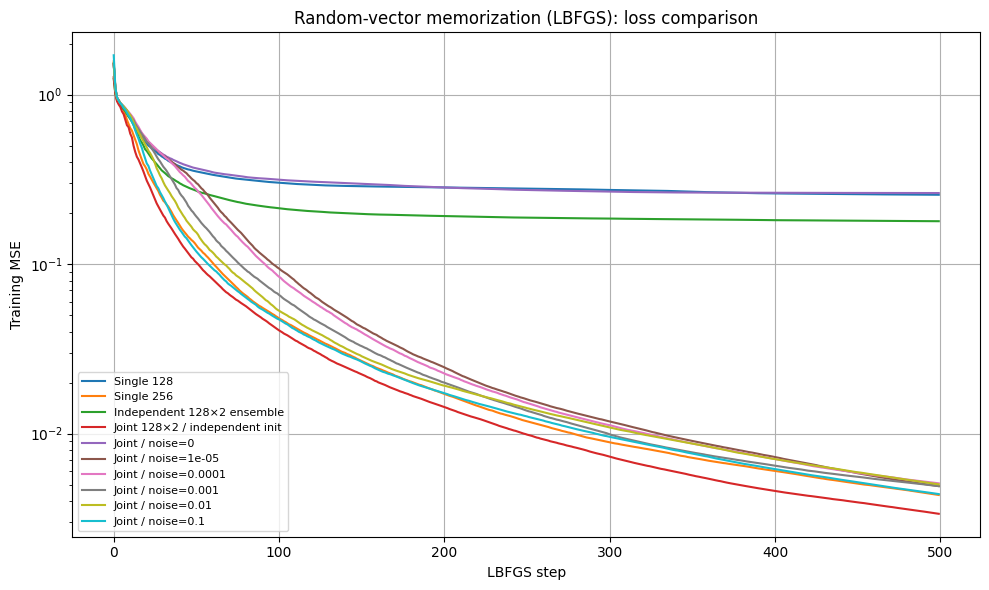

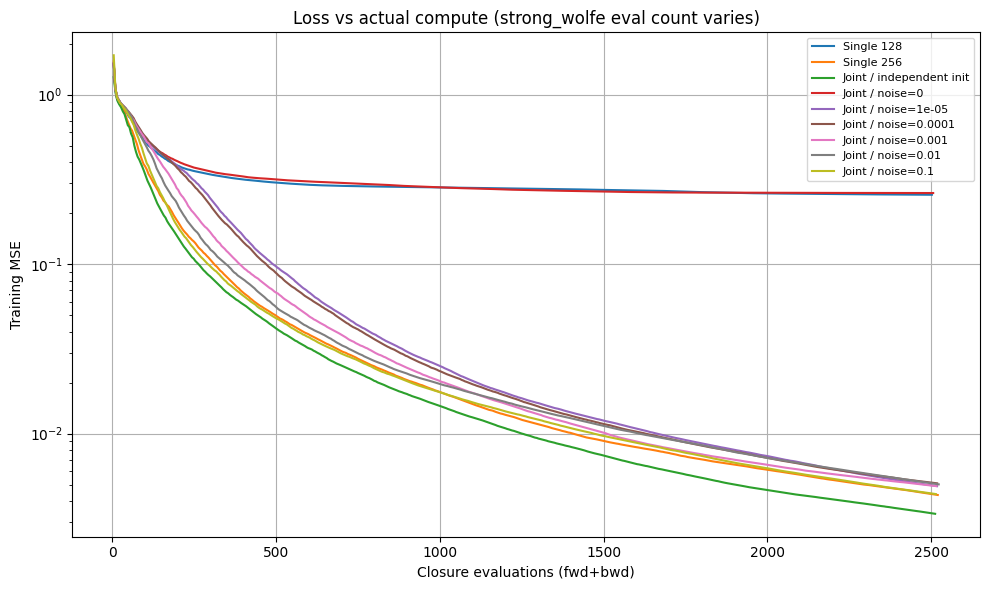

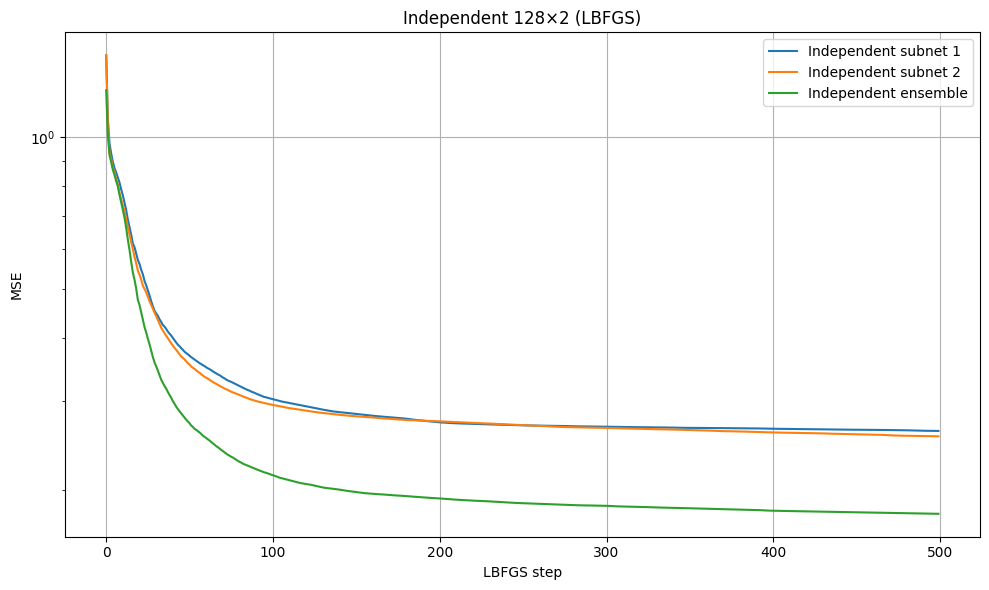

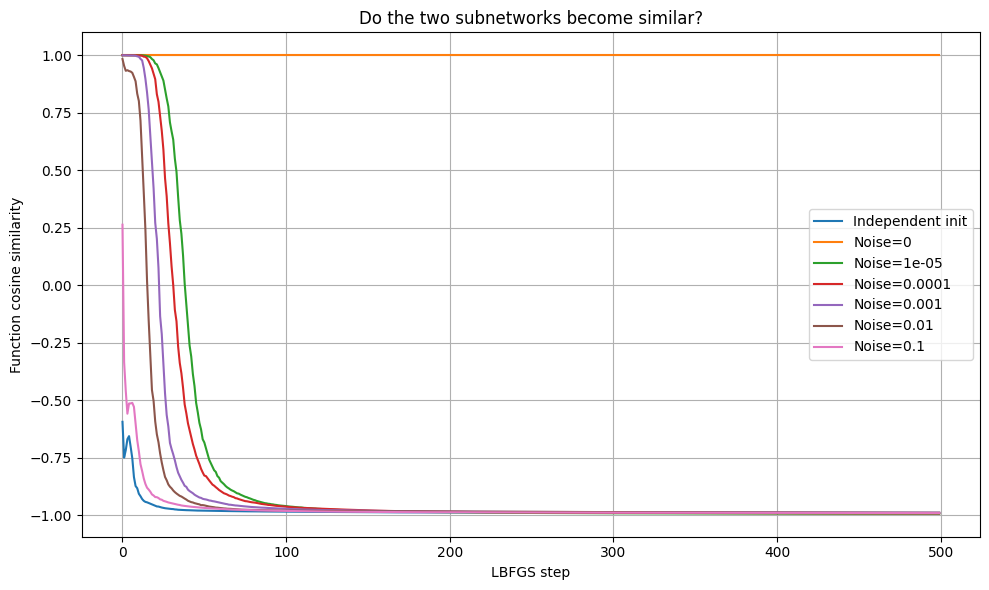

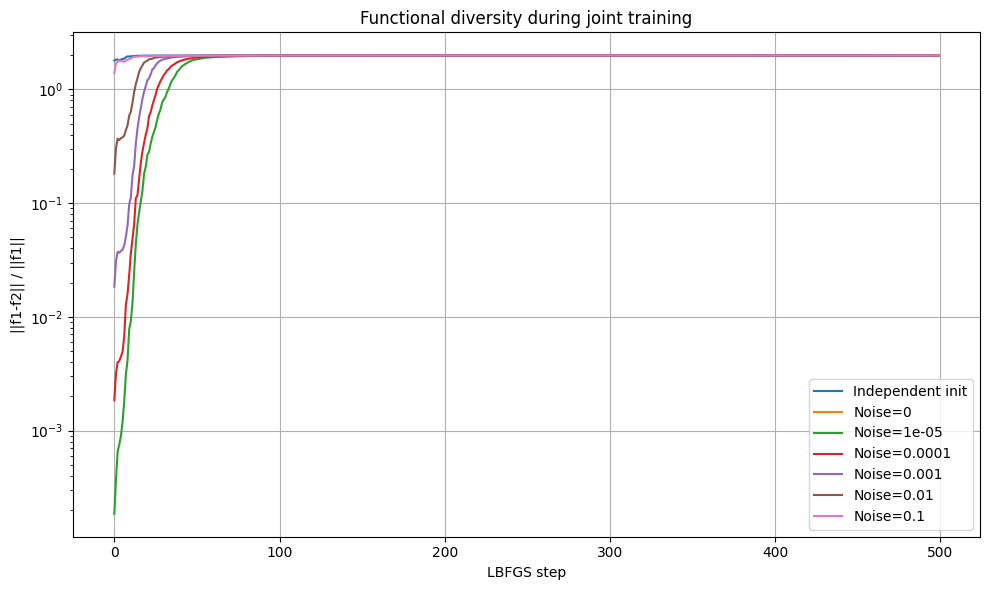

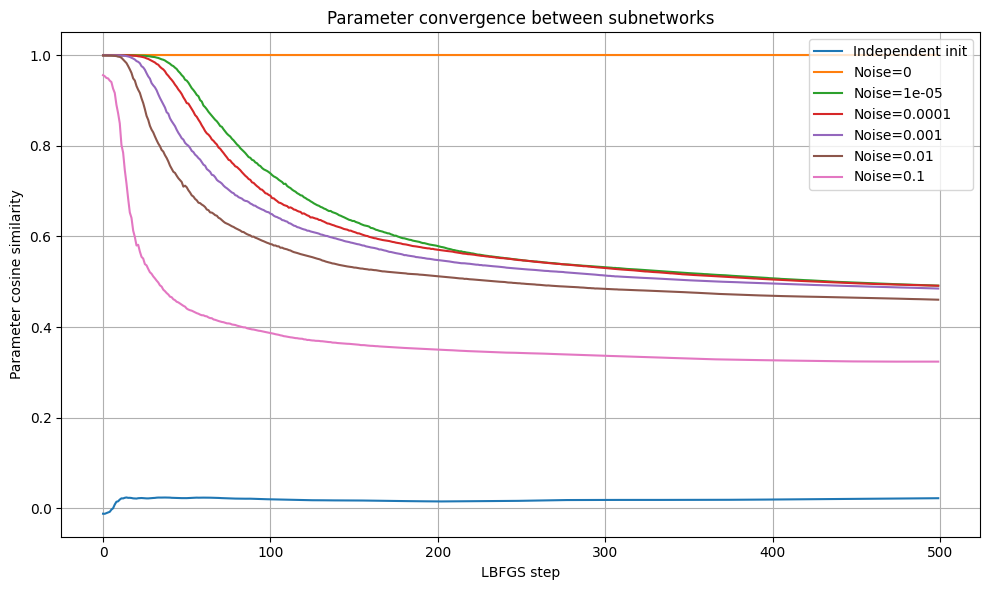

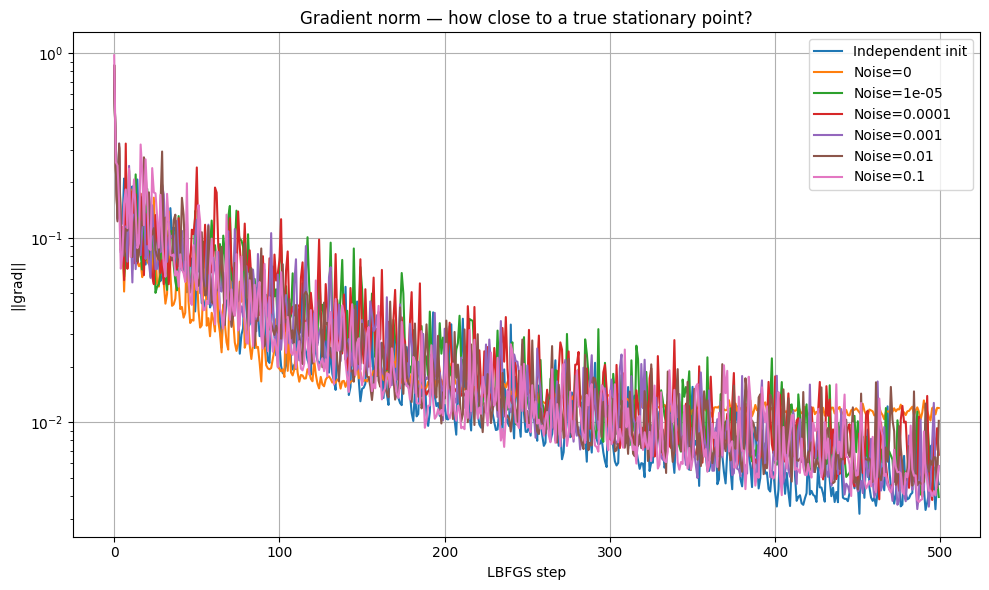

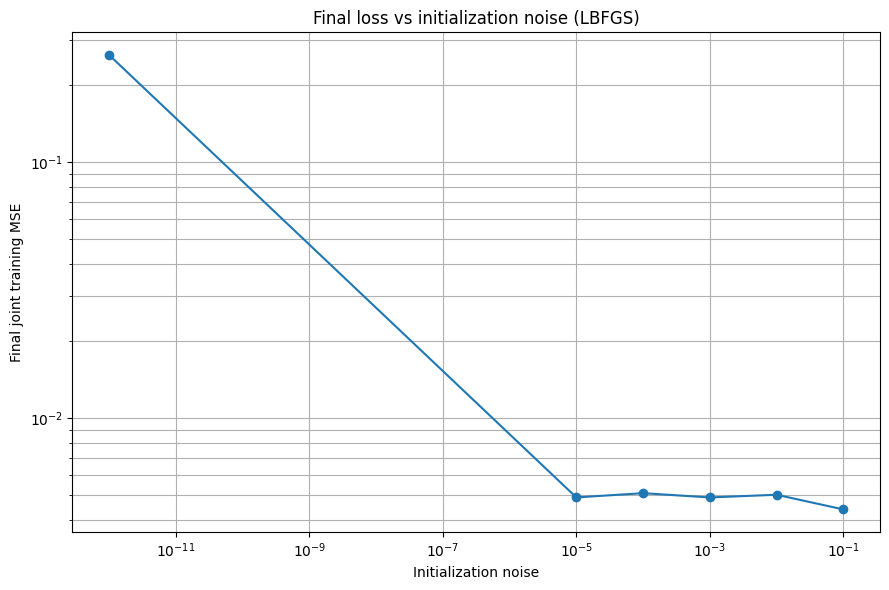

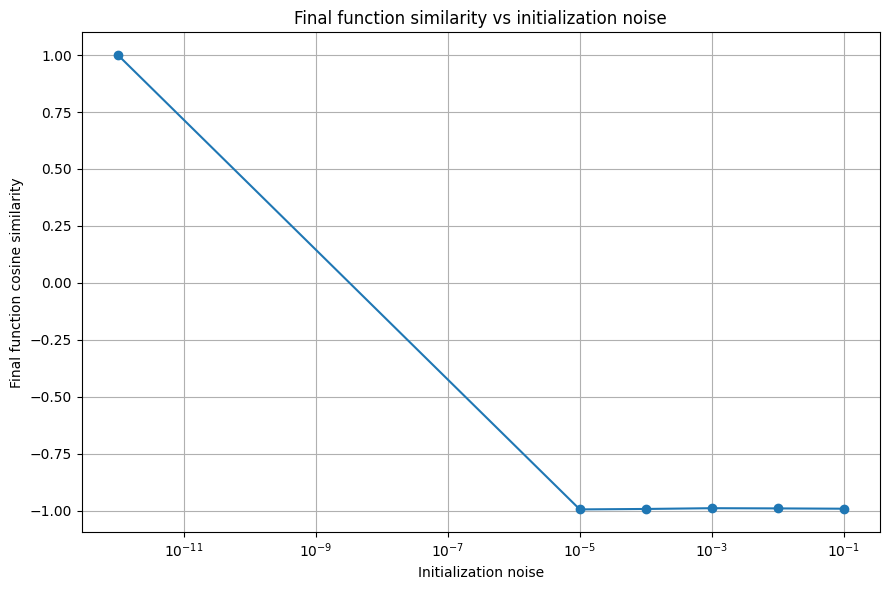

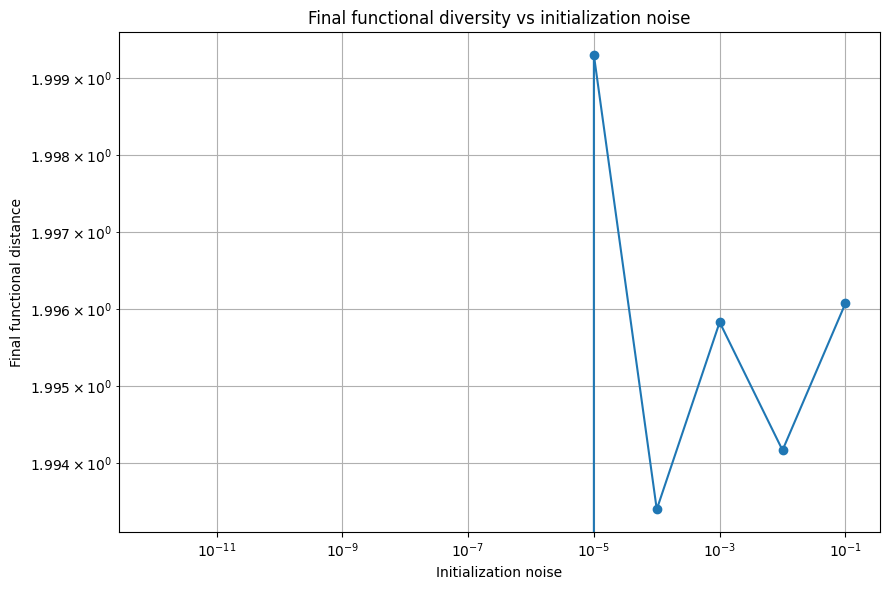

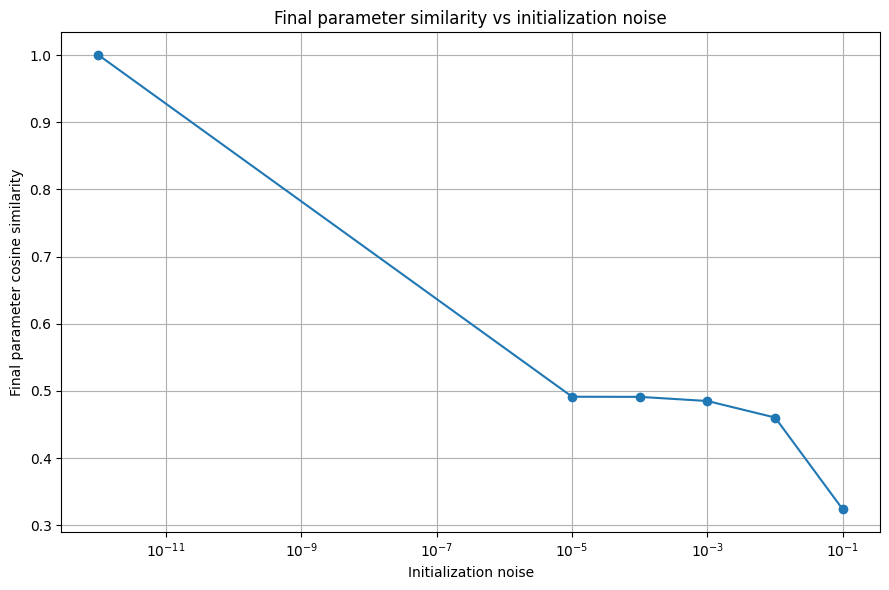

In [2]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ============================================================
# 0. Configuration
# ============================================================

SEED = 42

N = 512
INPUT_DIM = 10
OUTPUT_DIM = 10

HIDDEN_DIM = 128

# --- LBFGS specific ---------------------------------------
#
# One "epoch" here = one optimizer.step(closure) call,
# which internally runs up to LBFGS_MAX_ITER quasi-Newton
# iterations. So total inner iterations = EPOCHS * MAX_ITER.
#
EPOCHS = 500
LBFGS_MAX_ITER = 4
LBFGS_HISTORY = 50
LBFGS_LR = 1.0
LINE_SEARCH = "strong_wolfe"     # or None for fixed step

# LBFGS defaults (tolerance_grad=1e-7, tolerance_change=1e-9)
# cause the inner loop to bail out early once the loss gets
# small — which is exactly the regime we care about here.
# Set to 0 to force the full MAX_ITER every step.
TOL_GRAD = 0.0
TOL_CHANGE = 0.0

# LBFGS + memorization easily hits the float32 floor (~1e-7).
# Flip this to True to actually see the separation.
USE_DOUBLE = True

# Re-seed before every run so that subnet1's init is identical
# across all noise levels (otherwise the noise sweep is
# confounded by a different base init each time).
RESEED_EACH_RUN = True

DTYPE = torch.float64 if USE_DOUBLE else torch.float32

# Same init + perturbation
NOISE_LEVELS = [
    0.0,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)
print("dtype :", DTYPE)


# ============================================================
# 1. Reproducibility
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ============================================================
# 2. Random memorization dataset
# ============================================================

X = torch.randn(
    N,
    INPUT_DIM,
    device=device,
    dtype=DTYPE
)

Y = torch.randn(
    N,
    OUTPUT_DIM,
    device=device,
    dtype=DTYPE
)


# ============================================================
# 3. MLP
# ============================================================

class MLP(nn.Module):

    def __init__(self, hidden_dim=128):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, OUTPUT_DIM)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# 4. Initialization
# ============================================================

def init_weights(m):

    if isinstance(m, nn.Linear):

        nn.init.kaiming_normal_(
            m.weight,
            nonlinearity="relu"
        )

        nn.init.zeros_(m.bias)


# ============================================================
# 5. Joint model
# ============================================================

class JointTwoSubnet(nn.Module):

    def __init__(self):

        super().__init__()

        self.subnet1 = MLP(128)
        self.subnet2 = MLP(128)

    def forward(self, x):

        y1 = self.subnet1(x)
        y2 = self.subnet2(x)

        ensemble = 0.5 * (y1 + y2)

        return ensemble, y1, y2


# ============================================================
# 6. Initialization for joint model
# ============================================================

def initialize_joint_independent(model):

    model.subnet1.apply(init_weights)
    model.subnet2.apply(init_weights)


def initialize_joint_near_identical(
    model,
    noise_std
):

    # First subnet
    model.subnet1.apply(init_weights)

    # Second subnet = first subnet + noise
    with torch.no_grad():

        for p1, p2 in zip(
            model.subnet1.parameters(),
            model.subnet2.parameters()
        ):

            noise = (
                noise_std
                * torch.randn_like(p1)
            )

            p2.copy_(p1 + noise)


# ============================================================
# 7. Metrics
# ============================================================

@torch.no_grad()
def flatten_parameters(model):

    return torch.cat([
        p.detach().flatten()
        for p in model.parameters()
    ])


@torch.no_grad()
def parameter_cosine_similarity(
    model1,
    model2
):

    p1 = flatten_parameters(model1)
    p2 = flatten_parameters(model2)

    return torch.nn.functional.cosine_similarity(
        p1.unsqueeze(0),
        p2.unsqueeze(0)
    ).item()


@torch.no_grad()
def function_cosine_similarity(
    model1,
    model2,
    X
):

    y1 = model1(X).flatten()
    y2 = model2(X).flatten()

    return torch.nn.functional.cosine_similarity(
        y1.unsqueeze(0),
        y2.unsqueeze(0)
    ).item()


@torch.no_grad()
def relative_function_distance(
    model1,
    model2,
    X
):

    y1 = model1(X)
    y2 = model2(X)

    numerator = torch.norm(y1 - y2)
    denominator = torch.norm(y1) + 1e-12

    return (
        numerator / denominator
    ).item()


@torch.no_grad()
def grad_norm(params):

    total = 0.0

    for p in params:
        if p.grad is not None:
            total += p.grad.detach().pow(2).sum().item()

    return math.sqrt(total)


# ============================================================
# 8. LBFGS helpers
# ============================================================

def make_lbfgs(params):

    return torch.optim.LBFGS(
        params,
        lr=LBFGS_LR,
        max_iter=LBFGS_MAX_ITER,
        history_size=LBFGS_HISTORY,
        line_search_fn=LINE_SEARCH,
        tolerance_grad=TOL_GRAD,
        tolerance_change=TOL_CHANGE,
    )


class ClosureCounter:
    """
    strong_wolfe line search calls the closure a variable
    number of times per step, so a plain "epoch" axis is not
    a fair compute axis. Track function evaluations too.
    """

    def __init__(self):
        self.n = 0


def make_closure(
    optimizer,
    forward_loss_fn,
    counter
):
    """
    forward_loss_fn: () -> scalar tensor (with graph)
    """

    def closure():

        optimizer.zero_grad(set_to_none=True)

        loss = forward_loss_fn()

        loss.backward()

        counter.n += 1

        return loss

    return closure


def is_bad(x):
    return (not math.isfinite(x))


# ============================================================
# 9. Train single NN
# ============================================================

def train_single(
    hidden_dim,
    epochs=EPOCHS,
    seed=SEED
):

    if RESEED_EACH_RUN:
        set_seed(seed)

    model = MLP(hidden_dim).to(device=device, dtype=DTYPE)

    model.apply(init_weights)

    optimizer = make_lbfgs(model.parameters())

    loss_fn = nn.MSELoss()

    counter = ClosureCounter()

    closure = make_closure(
        optimizer,
        lambda: loss_fn(model(X), Y),
        counter
    )

    history = []
    nfev_history = []

    for epoch in range(epochs):

        optimizer.step(closure)

        # NOTE: step() returns the loss BEFORE the update
        # (the first closure evaluation), so re-evaluate.
        with torch.no_grad():
            current = loss_fn(model(X), Y).item()

        if is_bad(current):
            print(
                f"  [warn] non-finite loss at step {epoch}, "
                f"stopping early"
            )
            break

        history.append(current)
        nfev_history.append(counter.n)

    return model, history, nfev_history


# ============================================================
# 10. Train independent 128 × 2
# ============================================================

def train_independent_two(
    epochs=EPOCHS,
    seed=SEED
):

    if RESEED_EACH_RUN:
        set_seed(seed)

    model1 = MLP(128).to(device=device, dtype=DTYPE)
    model2 = MLP(128).to(device=device, dtype=DTYPE)

    model1.apply(init_weights)
    model2.apply(init_weights)

    optimizer1 = make_lbfgs(model1.parameters())
    optimizer2 = make_lbfgs(model2.parameters())

    loss_fn = nn.MSELoss()

    counter1 = ClosureCounter()
    counter2 = ClosureCounter()

    closure1 = make_closure(
        optimizer1,
        lambda: loss_fn(model1(X), Y),
        counter1
    )

    closure2 = make_closure(
        optimizer2,
        lambda: loss_fn(model2(X), Y),
        counter2
    )

    history = {
        "loss1": [],
        "loss2": [],
        "ensemble_loss": [],
        "param_cos": [],
        "func_cos": [],
        "func_dist": [],
        "nfev": [],
    }

    for epoch in range(epochs):

        optimizer1.step(closure1)
        optimizer2.step(closure2)

        with torch.no_grad():

            pred1 = model1(X)
            pred2 = model2(X)

            loss1 = loss_fn(pred1, Y).item()
            loss2 = loss_fn(pred2, Y).item()

            ensemble = (
                0.5 * pred1
                + 0.5 * pred2
            )

            ensemble_loss = loss_fn(
                ensemble,
                Y
            ).item()

            pcos = parameter_cosine_similarity(
                model1,
                model2
            )

            fcos = function_cosine_similarity(
                model1,
                model2,
                X
            )

            fdist = relative_function_distance(
                model1,
                model2,
                X
            )

        if is_bad(loss1) or is_bad(loss2):
            print(
                f"  [warn] non-finite loss at step {epoch}, "
                f"stopping early"
            )
            break

        history["loss1"].append(loss1)
        history["loss2"].append(loss2)
        history["ensemble_loss"].append(ensemble_loss)
        history["param_cos"].append(pcos)
        history["func_cos"].append(fcos)
        history["func_dist"].append(fdist)
        history["nfev"].append(counter1.n + counter2.n)

    return model1, model2, history


# ============================================================
# 11. Train joint model
# ============================================================

def train_joint(
    mode,
    noise_std=0.0,
    epochs=EPOCHS,
    seed=SEED
):

    if RESEED_EACH_RUN:
        set_seed(seed)

    model = JointTwoSubnet().to(device=device, dtype=DTYPE)

    if mode == "independent":

        initialize_joint_independent(
            model
        )

    elif mode == "near_identical":

        initialize_joint_near_identical(
            model,
            noise_std
        )

    else:

        raise ValueError(
            "Unknown initialization mode"
        )

    optimizer = make_lbfgs(model.parameters())

    loss_fn = nn.MSELoss()

    counter = ClosureCounter()

    # IMPORTANT:
    #
    # Joint model optimizes ONLY
    #
    #       || (f1 + f2)/2 - Y ||²
    #
    # not individual subnet losses.
    #
    # NOTE for LBFGS: this objective has an exactly flat
    # direction (f1 + d, f2 - d), so the Hessian is rank
    # deficient. The two-loop recursion tolerates this, but
    # curvature pairs along the flat subspace are numerically
    # junk — that's why we keep history_size finite and let
    # strong_wolfe reject bad steps.
    #
    def joint_loss():

        ensemble, y1, y2 = model(X)

        return loss_fn(ensemble, Y)

    closure = make_closure(
        optimizer,
        joint_loss,
        counter
    )

    history = {

        "loss": [],

        "subnet1_loss": [],
        "subnet2_loss": [],

        "param_cos": [],
        "func_cos": [],
        "func_dist": [],

        "grad_norm": [],
        "nfev": [],
    }

    for epoch in range(epochs):

        optimizer.step(closure)

        with torch.no_grad():

            ensemble, y1, y2 = model(X)

            loss = loss_fn(ensemble, Y).item()

            subnet1_loss = loss_fn(
                y1,
                Y
            ).item()

            subnet2_loss = loss_fn(
                y2,
                Y
            ).item()

            pcos = parameter_cosine_similarity(
                model.subnet1,
                model.subnet2
            )

            fcos = function_cosine_similarity(
                model.subnet1,
                model.subnet2,
                X
            )

            fdist = relative_function_distance(
                model.subnet1,
                model.subnet2,
                X
            )

        if is_bad(loss):
            print(
                f"  [warn] non-finite loss at step {epoch}, "
                f"stopping early"
            )
            break

        history["loss"].append(loss)
        history["subnet1_loss"].append(subnet1_loss)
        history["subnet2_loss"].append(subnet2_loss)
        history["param_cos"].append(pcos)
        history["func_cos"].append(fcos)
        history["func_dist"].append(fdist)
        history["grad_norm"].append(
            grad_norm(list(model.parameters()))
        )
        history["nfev"].append(counter.n)

    return model, history


# ============================================================
# 12. Train everything
# ============================================================

print("\n==============================")
print("1. Single 128")
print("==============================")

single128, h_single128, nfev_single128 = train_single(
    128,
    EPOCHS
)


print("\n==============================")
print("2. Single 256")
print("==============================")

single256, h_single256, nfev_single256 = train_single(
    256,
    EPOCHS
)


print("\n==============================")
print("3. Independent 128 × 2")
print("==============================")

ind1, ind2, h_independent = (
    train_independent_two(
        EPOCHS
    )
)


print("\n==============================")
print("4. Joint 128 × 2 / independent init")
print("==============================")

joint_ind, h_joint_ind = train_joint(
    mode="independent",
    epochs=EPOCHS
)


# ============================================================
# 13. Noise-level experiments
# ============================================================

noise_results = {}

for noise in NOISE_LEVELS:

    print("\n==============================")
    print(
        f"5. Joint 128 × 2 / "
        f"noise = {noise}"
    )
    print("==============================")

    model, history = train_joint(
        mode="near_identical",
        noise_std=noise,
        epochs=EPOCHS
    )

    noise_results[noise] = {
        "model": model,
        "history": history
    }


# ============================================================
# 14. Final summary
# ============================================================

print("\n\n========================================")
print("FINAL RESULTS  (LBFGS)")
print("========================================")

print(
    f"outer steps = {EPOCHS}, "
    f"max_iter = {LBFGS_MAX_ITER}, "
    f"line_search = {LINE_SEARCH}"
)

print(
    f"Single 128 final loss: "
    f"{h_single128[-1]:.8e}  "
    f"(nfev={nfev_single128[-1]})"
)

print(
    f"Single 256 final loss: "
    f"{h_single256[-1]:.8e}  "
    f"(nfev={nfev_single256[-1]})"
)

print(
    f"Independent 128×2 ensemble loss: "
    f"{h_independent['ensemble_loss'][-1]:.8e}"
)

print(
    f"Joint 128×2 independent-init loss: "
    f"{h_joint_ind['loss'][-1]:.8e}  "
    f"(nfev={h_joint_ind['nfev'][-1]})"
)


print("\nNoise experiments")
print("----------------------------------------")

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    print(
        f"noise={noise:<8g} "
        f"loss={h['loss'][-1]:.4e} "
        f"param_cos={h['param_cos'][-1]:.6f} "
        f"func_cos={h['func_cos'][-1]:.6f} "
        f"func_dist={h['func_dist'][-1]:.6f} "
        f"|g|={h['grad_norm'][-1]:.3e}"
    )


# ============================================================
# 15. Plot 1:
#     Main loss comparison
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_single128,
    label="Single 128"
)

plt.plot(
    h_single256,
    label="Single 256"
)

plt.plot(
    h_independent["ensemble_loss"],
    label="Independent 128×2 ensemble"
)

plt.plot(
    h_joint_ind["loss"],
    label="Joint 128×2 / independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["loss"],
        label=f"Joint / noise={noise:g}"
    )


plt.yscale("log")

plt.xlabel("LBFGS step")
plt.ylabel("Training MSE")

plt.title(
    "Random-vector memorization (LBFGS): "
    "loss comparison"
)

plt.legend(fontsize=8)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 16. Plot 1b:
#     Loss vs closure evaluations (fair compute axis)
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    nfev_single128,
    h_single128,
    label="Single 128"
)

plt.plot(
    nfev_single256,
    h_single256,
    label="Single 256"
)

plt.plot(
    h_joint_ind["nfev"],
    h_joint_ind["loss"],
    label="Joint / independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["nfev"],
        h["loss"],
        label=f"Joint / noise={noise:g}"
    )


plt.yscale("log")

plt.xlabel("Closure evaluations (fwd+bwd)")
plt.ylabel("Training MSE")

plt.title(
    "Loss vs actual compute "
    "(strong_wolfe eval count varies)"
)

plt.legend(fontsize=8)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 17. Plot 2:
#     Independent 128×2 individual vs ensemble
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_independent["loss1"],
    label="Independent subnet 1"
)

plt.plot(
    h_independent["loss2"],
    label="Independent subnet 2"
)

plt.plot(
    h_independent["ensemble_loss"],
    label="Independent ensemble"
)

plt.yscale("log")

plt.xlabel("LBFGS step")
plt.ylabel("MSE")

plt.title(
    "Independent 128×2 (LBFGS)"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 18. Plot 3:
#     Function similarity vs training
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_joint_ind["func_cos"],
    label="Independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["func_cos"],
        label=f"Noise={noise:g}"
    )


plt.xlabel("LBFGS step")

plt.ylabel(
    "Function cosine similarity"
)

plt.title(
    "Do the two subnetworks become similar?"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 19. Plot 4:
#     Functional distance
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_joint_ind["func_dist"],
    label="Independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["func_dist"],
        label=f"Noise={noise:g}"
    )


plt.yscale("log")

plt.xlabel("LBFGS step")

plt.ylabel(
    "||f1-f2|| / ||f1||"
)

plt.title(
    "Functional diversity during joint training"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 20. Plot 5:
#     Parameter similarity
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_joint_ind["param_cos"],
    label="Independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["param_cos"],
        label=f"Noise={noise:g}"
    )


plt.xlabel("LBFGS step")

plt.ylabel(
    "Parameter cosine similarity"
)

plt.title(
    "Parameter convergence between subnetworks"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 21. Plot 6:
#     Gradient norm (LBFGS convergence diagnostic)
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    h_joint_ind["grad_norm"],
    label="Independent init"
)

for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    plt.plot(
        h["grad_norm"],
        label=f"Noise={noise:g}"
    )


plt.yscale("log")

plt.xlabel("LBFGS step")
plt.ylabel("||grad||")

plt.title(
    "Gradient norm — how close to a true stationary point?"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 22. Plot 7:
#     Final noise sweep
# ============================================================

final_losses = []
final_func_cos = []
final_func_dist = []
final_param_cos = []


for noise in NOISE_LEVELS:

    h = noise_results[noise]["history"]

    final_losses.append(
        h["loss"][-1]
    )

    final_func_cos.append(
        h["func_cos"][-1]
    )

    final_func_dist.append(
        h["func_dist"][-1]
    )

    final_param_cos.append(
        h["param_cos"][-1]
    )


noise_x = np.maximum(NOISE_LEVELS, 1e-12)


# ---- loss ----

plt.figure(figsize=(9, 6))

plt.loglog(
    noise_x,
    final_losses,
    marker="o"
)

plt.xlabel(
    "Initialization noise"
)

plt.ylabel(
    "Final joint training MSE"
)

plt.title(
    "Final loss vs initialization noise (LBFGS)"
)

plt.grid(True, which="both")

plt.tight_layout()

plt.show()


# ---- function similarity ----

plt.figure(figsize=(9, 6))

plt.semilogx(
    noise_x,
    final_func_cos,
    marker="o"
)

plt.xlabel(
    "Initialization noise"
)

plt.ylabel(
    "Final function cosine similarity"
)

plt.title(
    "Final function similarity vs initialization noise"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ---- function distance ----

plt.figure(figsize=(9, 6))

plt.loglog(
    noise_x,
    final_func_dist,
    marker="o"
)

plt.xlabel(
    "Initialization noise"
)

plt.ylabel(
    "Final functional distance"
)

plt.title(
    "Final functional diversity vs initialization noise"
)

plt.grid(True, which="both")

plt.tight_layout()

plt.show()


# ---- parameter similarity ----

plt.figure(figsize=(9, 6))

plt.semilogx(
    noise_x,
    final_param_cos,
    marker="o"
)

plt.xlabel(
    "Initialization noise"
)

plt.ylabel(
    "Final parameter cosine similarity"
)

plt.title(
    "Final parameter similarity vs initialization noise"
)

plt.grid(True)

plt.tight_layout()

plt.show()

device: cpu | dtype: torch.float64

k = 2  (independent init)
  final loss      = 3.5337e-03
  mean pair cos   = -0.99221   (simplex baseline -1.00000)
  std  pair cos   = 0.00000
  max  pair cos   = -0.99221
  eff rank        = 1.026 / 1  (ratio 1.0258)
  collapsed pairs = 0 / 1
  ||f||/||Y||     = 15.994

k = 5  (independent init)
  final loss      = 2.1437e-09
  mean pair cos   = -0.24100   (simplex baseline -0.25000)
  std  pair cos   = 0.09960
  max  pair cos   = -0.11602
  eff rank        = 4.036 / 4  (ratio 1.0091)
  collapsed pairs = 0 / 10
  ||f||/||Y||     = 15.477

k = 10  (independent init)
  final loss      = 4.8342e-10
  mean pair cos   = -0.10697   (simplex baseline -0.11111)
  std  pair cos   = 0.13564
  max  pair cos   = +0.22850
  eff rank        = 8.548 / 9  (ratio 0.9497)
  collapsed pairs = 0 / 45
  ||f||/||Y||     = 16.994

k = 50  (independent init)
  final loss      = 1.1595e-10
  mean pair cos   = -0.01765   (simplex baseline -0.02041)
  std  pair cos   = 0.122

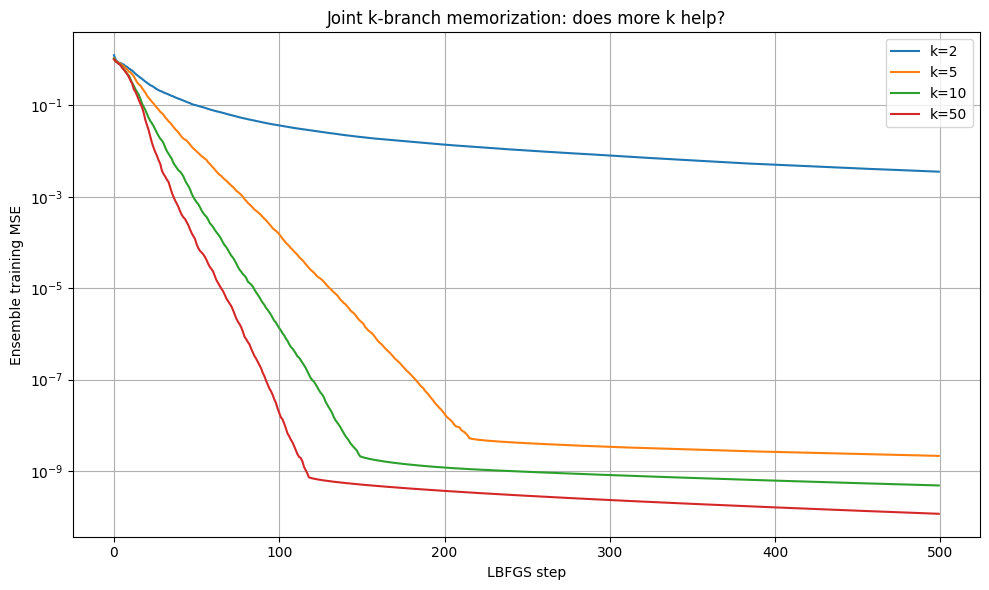

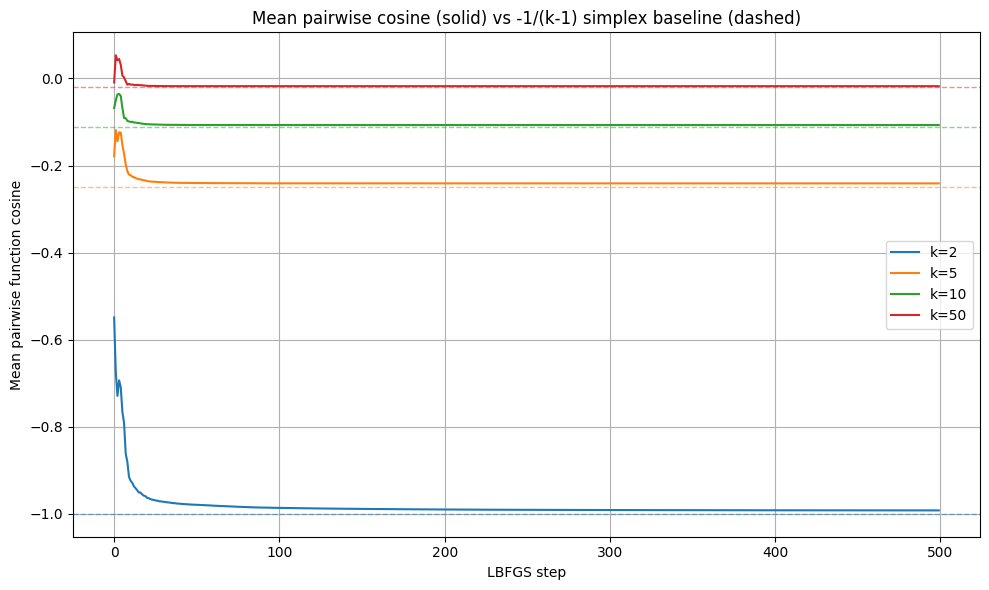

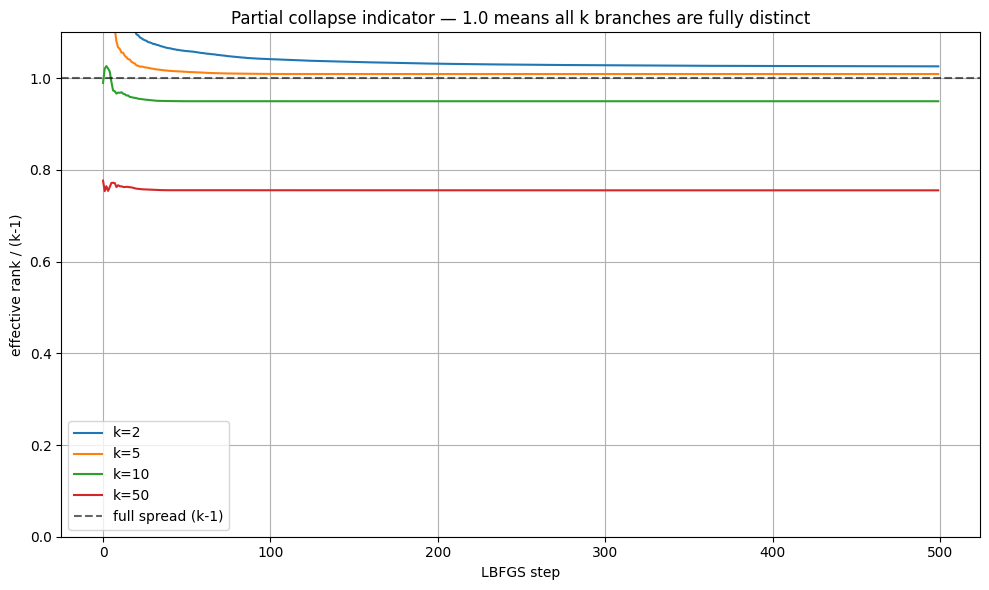

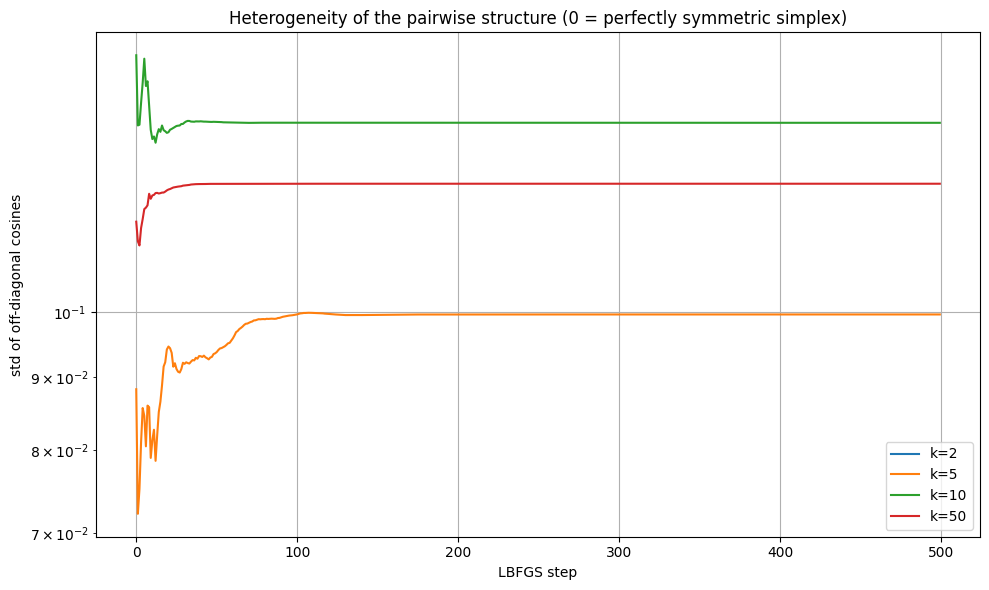

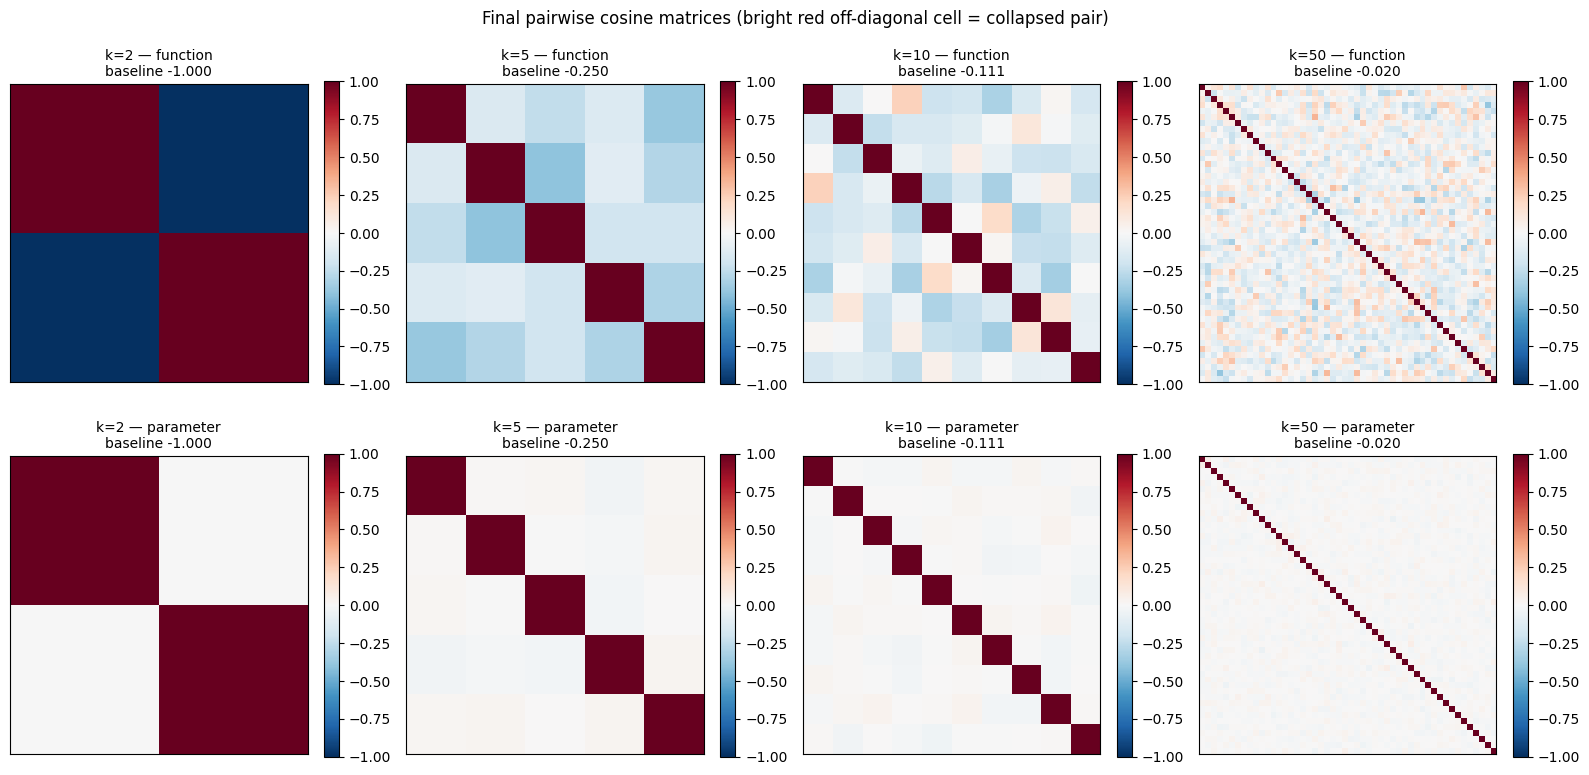

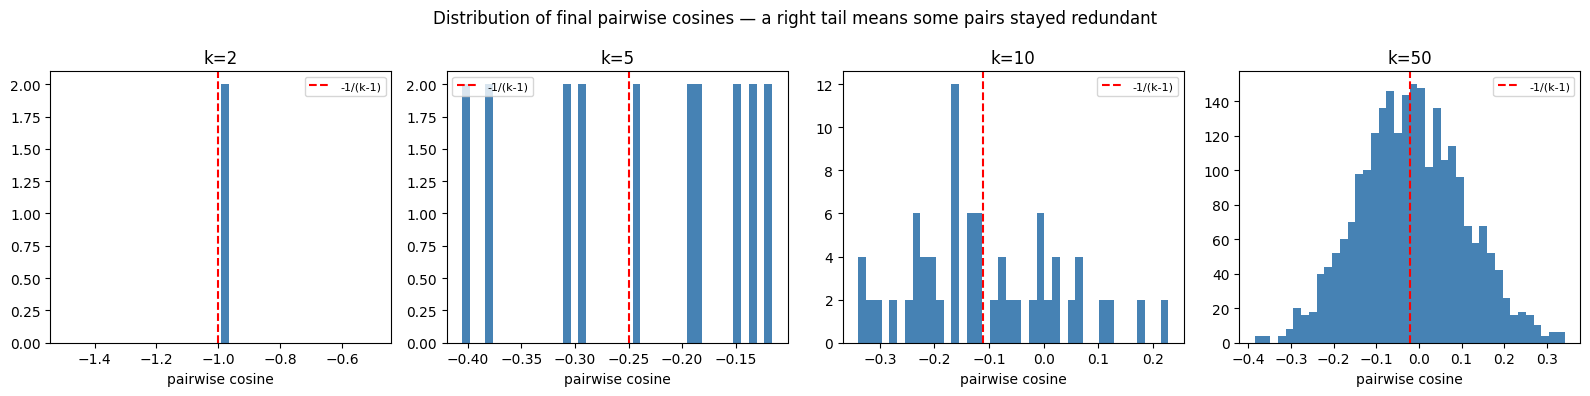

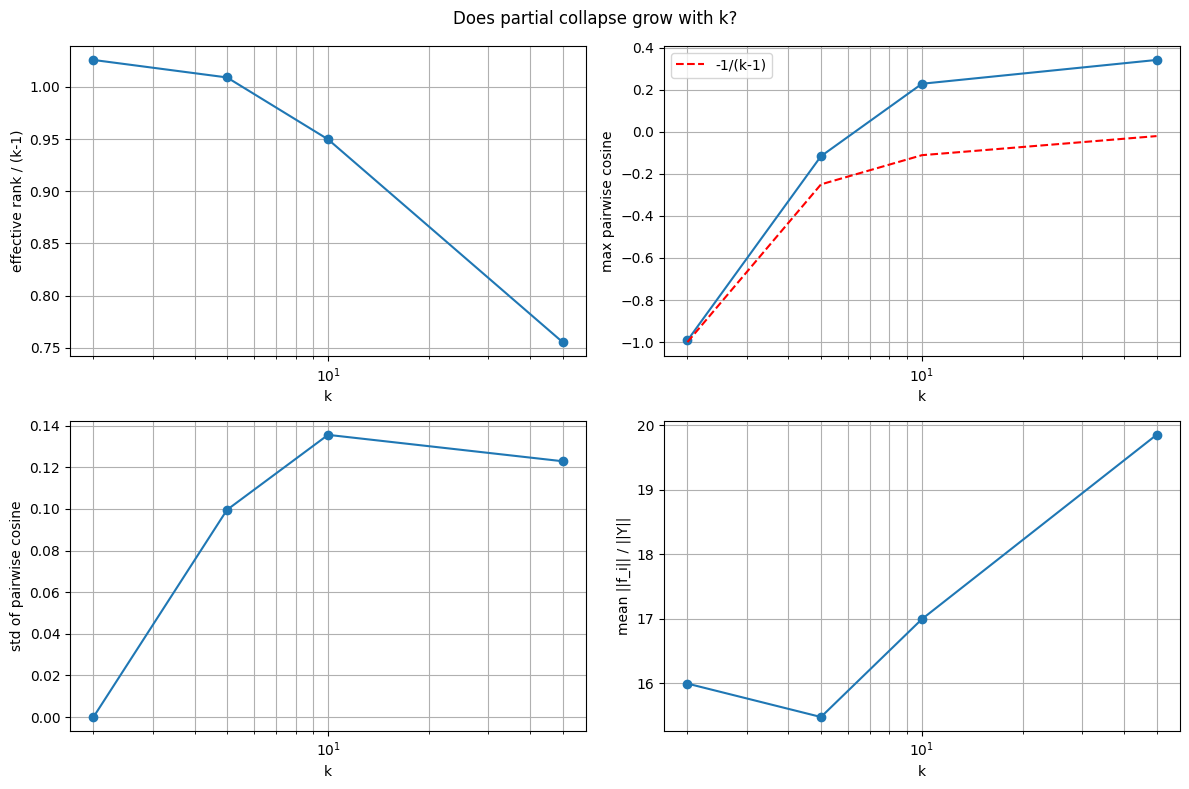

In [6]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ============================================================
# 0. Configuration
# ============================================================

SEED = 42

N = 512
INPUT_DIM = 10
OUTPUT_DIM = 10
HIDDEN_DIM = 128

K_LIST = [2, 5, 10, 50]

INIT_MODE = "independent"      # "independent" | "near_identical"
NOISE_STD = 1e-3               # only used for near_identical

EPOCHS = 500
LBFGS_MAX_ITER = 4
LBFGS_HISTORY = 50
LBFGS_LR = 1.0
LINE_SEARCH = "strong_wolfe"

TOL_GRAD = 0.0
TOL_CHANGE = 0.0

USE_DOUBLE = True

# A pair counts as "redundant" if its cosine sits well above
# the symmetric-simplex baseline of -1/(k-1).
COLLAPSE_MARGIN = 0.5

DTYPE = torch.float64 if USE_DOUBLE else torch.float32

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device, "| dtype:", DTYPE)


# ============================================================
# 1. Reproducibility
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ============================================================
# 2. Random memorization dataset
# ============================================================

X = torch.randn(N, INPUT_DIM, device=device, dtype=DTYPE)
Y = torch.randn(N, OUTPUT_DIM, device=device, dtype=DTYPE)


# ============================================================
# 3. Vectorized k-branch model
# ============================================================
#
# k separate 2-layer MLPs, batched with bmm so that k=50
# costs one kernel launch instead of fifty. Each branch is
# EXACTLY the same architecture as the original MLP(128).
#
# Params are stored as (k, ...) tensors, which also makes the
# per-branch parameter matrix trivial to extract.
#

class KBranchMLP(nn.Module):

    def __init__(
        self,
        k,
        in_dim=INPUT_DIM,
        hidden=HIDDEN_DIM,
        out_dim=OUTPUT_DIM
    ):

        super().__init__()

        self.k = k

        self.W1 = nn.Parameter(
            torch.empty(k, in_dim, hidden)
        )
        self.b1 = nn.Parameter(
            torch.zeros(k, 1, hidden)
        )
        self.W2 = nn.Parameter(
            torch.empty(k, hidden, out_dim)
        )
        self.b2 = nn.Parameter(
            torch.zeros(k, 1, out_dim)
        )

        self.reset_parameters()

    @torch.no_grad()
    def reset_parameters(self):

        # kaiming normal, fan_in mode, relu gain
        self.W1.normal_(
            0.0,
            math.sqrt(2.0 / self.W1.shape[1])
        )
        self.W2.normal_(
            0.0,
            math.sqrt(2.0 / self.W2.shape[1])
        )

        self.b1.zero_()
        self.b2.zero_()

    @torch.no_grad()
    def make_near_identical(self, noise_std):
        """
        Branch 0 stays as-is; every other branch is
        branch 0 + gaussian noise.
        """

        for p in [self.W1, self.b1, self.W2, self.b2]:

            base = p[0:1].clone()

            noise = noise_std * torch.randn_like(p)
            noise[0].zero_()

            p.copy_(base + noise)

    def branch_outputs(self, x):
        """
        returns (k, N, out_dim)
        """

        xb = x.unsqueeze(0).expand(self.k, -1, -1)

        h = torch.baddbmm(self.b1, xb, self.W1)
        h = torch.relu(h)

        return torch.baddbmm(self.b2, h, self.W2)

    def forward(self, x):

        f = self.branch_outputs(x)

        return f.mean(dim=0), f

    @torch.no_grad()
    def branch_param_matrix(self):
        """
        returns (k, P) — one flattened parameter vector
        per branch.
        """

        return torch.cat(
            [
                self.W1.reshape(self.k, -1),
                self.b1.reshape(self.k, -1),
                self.W2.reshape(self.k, -1),
                self.b2.reshape(self.k, -1),
            ],
            dim=1
        )


# ============================================================
# 4. Diversity metrics
# ============================================================

def normalized_gram(M, eps=1e-12):
    """
    M: (k, D)  ->  (k, k) cosine similarity matrix
    """

    Mn = M / (M.norm(dim=1, keepdim=True) + eps)

    return Mn @ Mn.t()


def offdiag(G):

    k = G.shape[0]

    mask = ~torch.eye(
        k,
        dtype=torch.bool,
        device=G.device
    )

    return G[mask]


def effective_rank(G, eps=1e-12):
    """
    Entropy-based effective rank of a PSD matrix.

    For k branches spread as a perfect symmetric simplex
    (every off-diagonal cosine = -1/(k-1)) this equals
    exactly k-1. Any partial collapse pushes it below.
    """

    ev = torch.linalg.eigvalsh(G)
    ev = torch.clamp(ev, min=0.0)

    total = ev.sum()

    if total <= eps:
        return 0.0

    p = ev / total
    p = p[p > eps]

    entropy = -(p * p.log()).sum()

    return entropy.exp().item()


@torch.no_grad()
def diversity_stats(model, X, Y):

    k = model.k

    f = model.branch_outputs(X)          # (k, N, d)
    F = f.reshape(k, -1)                 # (k, N*d)

    Gf = normalized_gram(F)
    Gp = normalized_gram(model.branch_param_matrix())

    off_f = offdiag(Gf)
    off_p = offdiag(Gp)

    baseline = -1.0 / (k - 1) if k > 1 else 0.0

    # how many pairs sit clearly above the simplex baseline
    n_collapsed = (
        off_f > (baseline + COLLAPSE_MARGIN)
    ).sum().item() / 2.0

    norm_ratio = (
        F.norm(dim=1).mean() / (Y.reshape(-1).norm() + 1e-12)
    ).item()

    return {
        "func_cos_mean": off_f.mean().item(),
        "func_cos_std": off_f.std().item(),
        "func_cos_max": off_f.max().item(),
        "param_cos_mean": off_p.mean().item(),
        "param_cos_max": off_p.max().item(),
        "eff_rank": effective_rank(Gf),
        "eff_rank_ratio": effective_rank(Gf) / max(k - 1, 1),
        "n_collapsed_pairs": n_collapsed,
        "norm_ratio": norm_ratio,
        "baseline": baseline,
        "Gf": Gf.cpu().numpy(),
        "Gp": Gp.cpu().numpy(),
    }


# ============================================================
# 5. Training
# ============================================================

def make_lbfgs(params):

    return torch.optim.LBFGS(
        params,
        lr=LBFGS_LR,
        max_iter=LBFGS_MAX_ITER,
        history_size=LBFGS_HISTORY,
        line_search_fn=LINE_SEARCH,
        tolerance_grad=TOL_GRAD,
        tolerance_change=TOL_CHANGE,
    )


def train_k_branch(
    k,
    epochs=EPOCHS,
    init_mode=INIT_MODE,
    noise_std=NOISE_STD,
    seed=SEED
):

    set_seed(seed)

    model = KBranchMLP(k).to(device=device, dtype=DTYPE)

    if init_mode == "near_identical":
        model.make_near_identical(noise_std)

    optimizer = make_lbfgs(model.parameters())

    loss_fn = nn.MSELoss()

    def closure():

        optimizer.zero_grad(set_to_none=True)

        ensemble, _ = model(X)

        loss = loss_fn(ensemble, Y)
        loss.backward()

        return loss

    history = {
        key: []
        for key in [
            "loss",
            "func_cos_mean",
            "func_cos_std",
            "func_cos_max",
            "param_cos_mean",
            "param_cos_max",
            "eff_rank",
            "eff_rank_ratio",
            "n_collapsed_pairs",
            "norm_ratio",
        ]
    }

    for epoch in range(epochs):

        optimizer.step(closure)

        with torch.no_grad():
            ensemble, _ = model(X)
            loss = loss_fn(ensemble, Y).item()

        if not math.isfinite(loss):
            print(f"  [warn] non-finite loss at step {epoch}")
            break

        stats = diversity_stats(model, X, Y)

        history["loss"].append(loss)

        for key in history:
            if key != "loss":
                history[key].append(stats[key])

    final_stats = diversity_stats(model, X, Y)

    return model, history, final_stats


# ============================================================
# 6. Run the sweep
# ============================================================

results = {}

for k in K_LIST:

    print("\n==============================")
    print(f"k = {k}  ({INIT_MODE} init)")
    print("==============================")

    model, history, final_stats = train_k_branch(k)

    results[k] = {
        "model": model,
        "history": history,
        "final": final_stats,
    }

    print(
        f"  final loss      = {history['loss'][-1]:.4e}\n"
        f"  mean pair cos   = {final_stats['func_cos_mean']:+.5f}"
        f"   (simplex baseline "
        f"{final_stats['baseline']:+.5f})\n"
        f"  std  pair cos   = {final_stats['func_cos_std']:.5f}\n"
        f"  max  pair cos   = {final_stats['func_cos_max']:+.5f}\n"
        f"  eff rank        = {final_stats['eff_rank']:.3f} / "
        f"{k - 1}  "
        f"(ratio {final_stats['eff_rank_ratio']:.4f})\n"
        f"  collapsed pairs = "
        f"{final_stats['n_collapsed_pairs']:.0f} / "
        f"{k * (k - 1) // 2}\n"
        f"  ||f||/||Y||     = {final_stats['norm_ratio']:.3f}"
    )


# ============================================================
# 7. Summary table
# ============================================================

print("\n\n============================================")
print("SUMMARY")
print("============================================")
print(
    f"{'k':>4} {'loss':>11} {'mean_cos':>10} "
    f"{'-1/(k-1)':>10} {'std':>8} {'max':>8} "
    f"{'effrank':>9} {'/(k-1)':>8}"
)

for k in K_LIST:

    s = results[k]["final"]
    h = results[k]["history"]

    print(
        f"{k:>4} {h['loss'][-1]:>11.3e} "
        f"{s['func_cos_mean']:>+10.5f} "
        f"{s['baseline']:>+10.5f} "
        f"{s['func_cos_std']:>8.4f} "
        f"{s['func_cos_max']:>+8.4f} "
        f"{s['eff_rank']:>9.3f} "
        f"{s['eff_rank_ratio']:>8.4f}"
    )


# ============================================================
# 8. Plot 1: loss vs k
# ============================================================

plt.figure(figsize=(10, 6))

for k in K_LIST:
    plt.plot(
        results[k]["history"]["loss"],
        label=f"k={k}"
    )

plt.yscale("log")
plt.xlabel("LBFGS step")
plt.ylabel("Ensemble training MSE")
plt.title("Joint k-branch memorization: does more k help?")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 9. Plot 2: mean pairwise cosine vs simplex baseline
# ============================================================

plt.figure(figsize=(10, 6))

for i, k in enumerate(K_LIST):

    color = f"C{i}"

    plt.plot(
        results[k]["history"]["func_cos_mean"],
        color=color,
        label=f"k={k}"
    )

    plt.axhline(
        -1.0 / (k - 1),
        color=color,
        linestyle="--",
        alpha=0.5,
        linewidth=1
    )

plt.xlabel("LBFGS step")
plt.ylabel("Mean pairwise function cosine")
plt.title(
    "Mean pairwise cosine (solid) vs -1/(k-1) simplex "
    "baseline (dashed)"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Plot 3: effective rank ratio
#     THE partial-collapse indicator
# ============================================================

plt.figure(figsize=(10, 6))

for k in K_LIST:
    plt.plot(
        results[k]["history"]["eff_rank_ratio"],
        label=f"k={k}"
    )

plt.axhline(
    1.0,
    color="k",
    linestyle="--",
    alpha=0.6,
    label="full spread (k-1)"
)

plt.xlabel("LBFGS step")
plt.ylabel("effective rank / (k-1)")
plt.title(
    "Partial collapse indicator — "
    "1.0 means all k branches are fully distinct"
)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Plot 4: spread of pairwise cosines
# ============================================================

plt.figure(figsize=(10, 6))

for k in K_LIST:

    h = results[k]["history"]

    plt.plot(
        h["func_cos_std"],
        label=f"k={k}"
    )

plt.yscale("log")
plt.xlabel("LBFGS step")
plt.ylabel("std of off-diagonal cosines")
plt.title(
    "Heterogeneity of the pairwise structure "
    "(0 = perfectly symmetric simplex)"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 12. Plot 5: final pairwise cosine matrices
# ============================================================

n = len(K_LIST)

fig, axes = plt.subplots(
    2,
    n,
    figsize=(4 * n, 8)
)

if n == 1:
    axes = axes.reshape(2, 1)

for j, k in enumerate(K_LIST):

    s = results[k]["final"]
    b = s["baseline"]

    for row, key, name in [
        (0, "Gf", "function"),
        (1, "Gp", "parameter"),
    ]:

        ax = axes[row, j]

        im = ax.imshow(
            s[key],
            cmap="RdBu_r",
            vmin=-1,
            vmax=1
        )

        ax.set_title(
            f"k={k} — {name}\n"
            f"baseline {b:+.3f}",
            fontsize=10
        )

        ax.set_xticks([])
        ax.set_yticks([])

        fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(
    "Final pairwise cosine matrices "
    "(bright red off-diagonal cell = collapsed pair)"
)
plt.tight_layout()
plt.show()


# ============================================================
# 13. Plot 6: histogram of final off-diagonal cosines
# ============================================================

fig, axes = plt.subplots(
    1,
    n,
    figsize=(4 * n, 4)
)

if n == 1:
    axes = [axes]

for ax, k in zip(axes, K_LIST):

    G = results[k]["final"]["Gf"]

    mask = ~np.eye(k, dtype=bool)
    vals = G[mask]

    ax.hist(vals, bins=40, color="steelblue")

    ax.axvline(
        -1.0 / (k - 1),
        color="red",
        linestyle="--",
        label="-1/(k-1)"
    )

    ax.set_title(f"k={k}")
    ax.set_xlabel("pairwise cosine")
    ax.legend(fontsize=8)

plt.suptitle(
    "Distribution of final pairwise cosines — "
    "a right tail means some pairs stayed redundant"
)
plt.tight_layout()
plt.show()


# ============================================================
# 14. Plot 7: scaling of collapse with k
# ============================================================

ks = np.array(K_LIST, dtype=float)

eff_ratio = np.array([
    results[k]["final"]["eff_rank_ratio"] for k in K_LIST
])

cos_max = np.array([
    results[k]["final"]["func_cos_max"] for k in K_LIST
])

cos_std = np.array([
    results[k]["final"]["func_cos_std"] for k in K_LIST
])

norm_ratio = np.array([
    results[k]["final"]["norm_ratio"] for k in K_LIST
])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, y, name in [
    (axes[0, 0], eff_ratio, "effective rank / (k-1)"),
    (axes[0, 1], cos_max, "max pairwise cosine"),
    (axes[1, 0], cos_std, "std of pairwise cosine"),
    (axes[1, 1], norm_ratio, "mean ||f_i|| / ||Y||"),
]:

    ax.semilogx(ks, y, marker="o")
    ax.set_xlabel("k")
    ax.set_ylabel(name)
    ax.grid(True, which="both")

axes[0, 1].semilogx(
    ks,
    -1.0 / (ks - 1),
    linestyle="--",
    color="red",
    label="-1/(k-1)"
)
axes[0, 1].legend()

plt.suptitle("Does partial collapse grow with k?")
plt.tight_layout()
plt.show()

device: cpu | dtype: torch.float64

k = 2  (near_identical init)
  final loss      = 4.7397e-03
  mean pair cos   = -0.98887   (simplex baseline -1.00000)
  std  pair cos   = 0.00000
  max  pair cos   = -0.98887
  eff rank        = 1.035 / 1  (ratio 1.0350)
  collapsed pairs = 0 / 1
  ||f||/||Y||     = 13.368

k = 5  (near_identical init)
  final loss      = 2.0480e-09
  mean pair cos   = -0.24024   (simplex baseline -0.25000)
  std  pair cos   = 0.11786
  max  pair cos   = -0.03789
  eff rank        = 4.051 / 4  (ratio 1.0128)
  collapsed pairs = 0 / 10
  ||f||/||Y||     = 11.714

k = 10  (near_identical init)
  final loss      = 5.6128e-10
  mean pair cos   = -0.10173   (simplex baseline -0.11111)
  std  pair cos   = 0.08508
  max  pair cos   = +0.09715
  eff rank        = 8.991 / 9  (ratio 0.9990)
  collapsed pairs = 0 / 45
  ||f||/||Y||     = 11.819

k = 50  (near_identical init)
  final loss      = 2.6378e-10
  mean pair cos   = -0.01423   (simplex baseline -0.02041)
  std  pair c

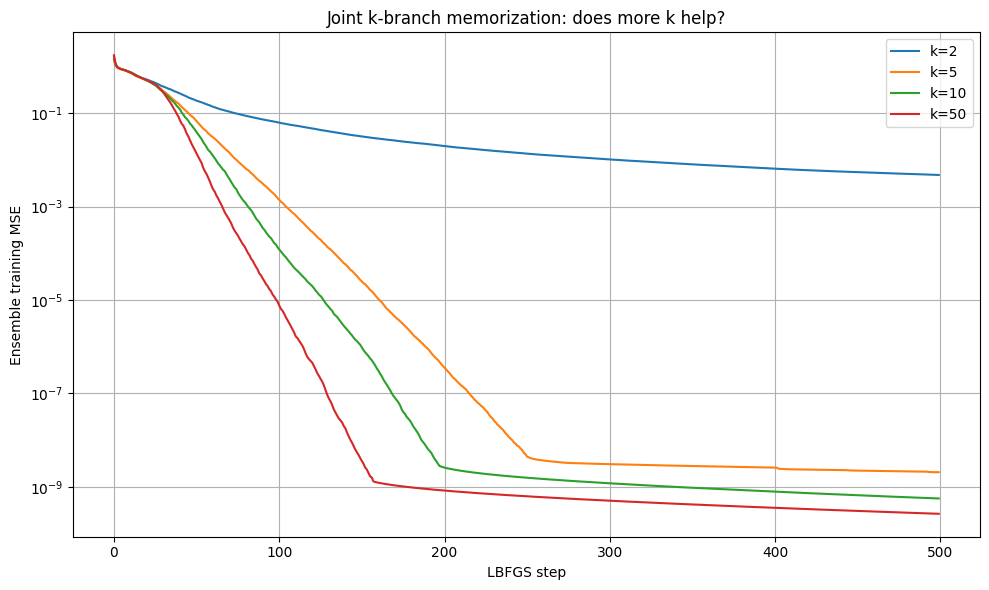

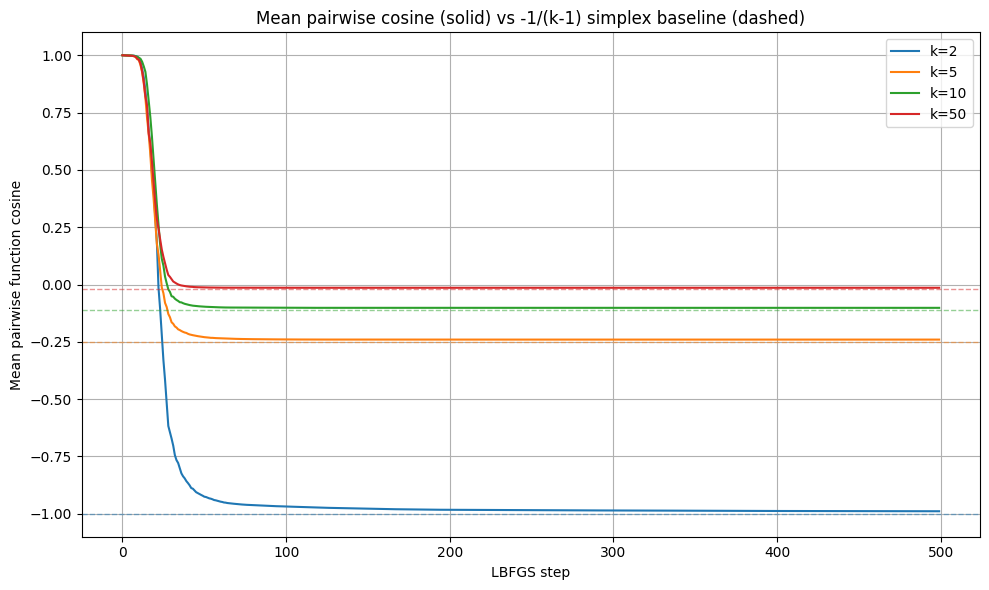

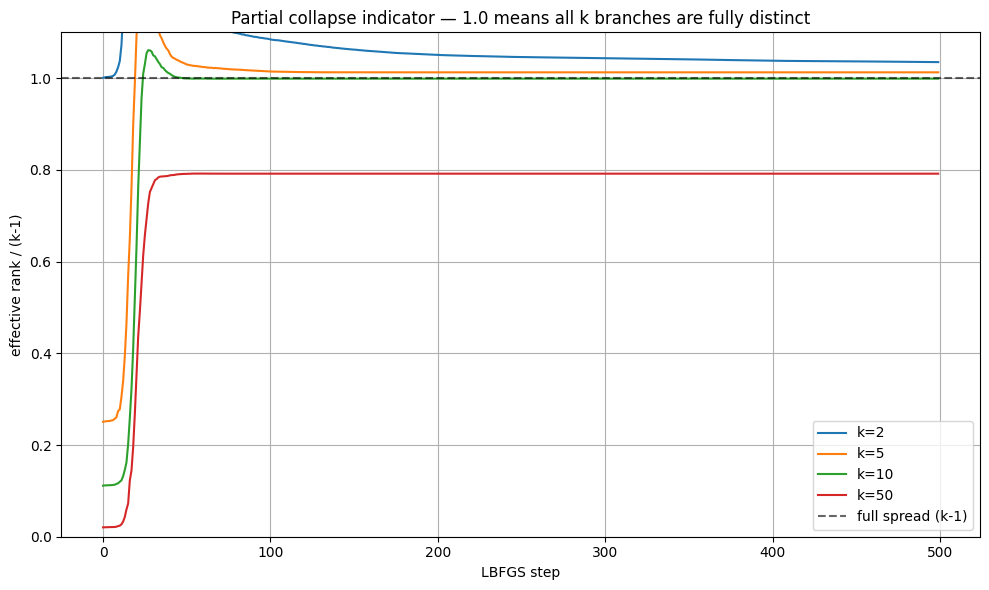

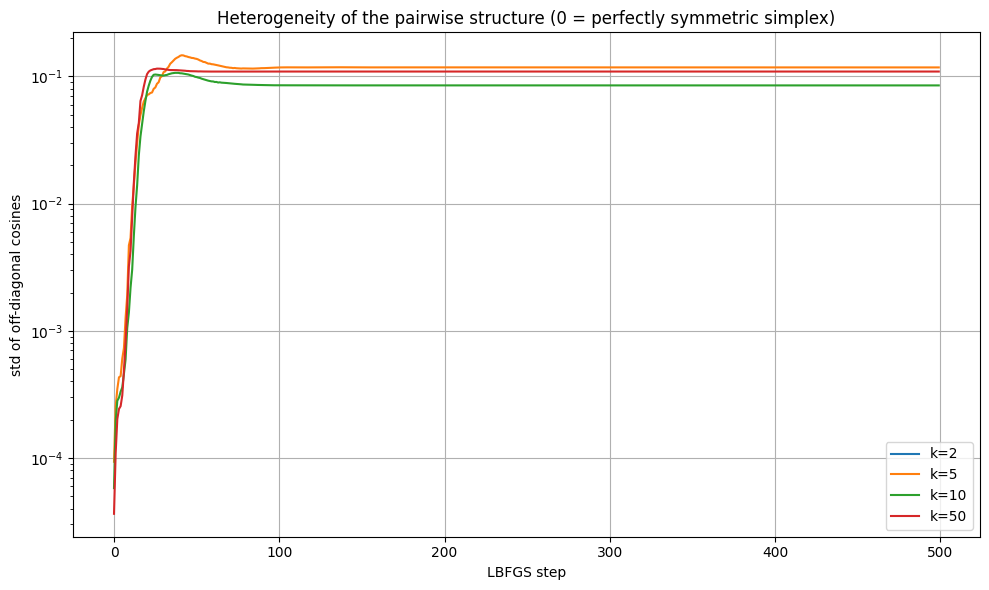

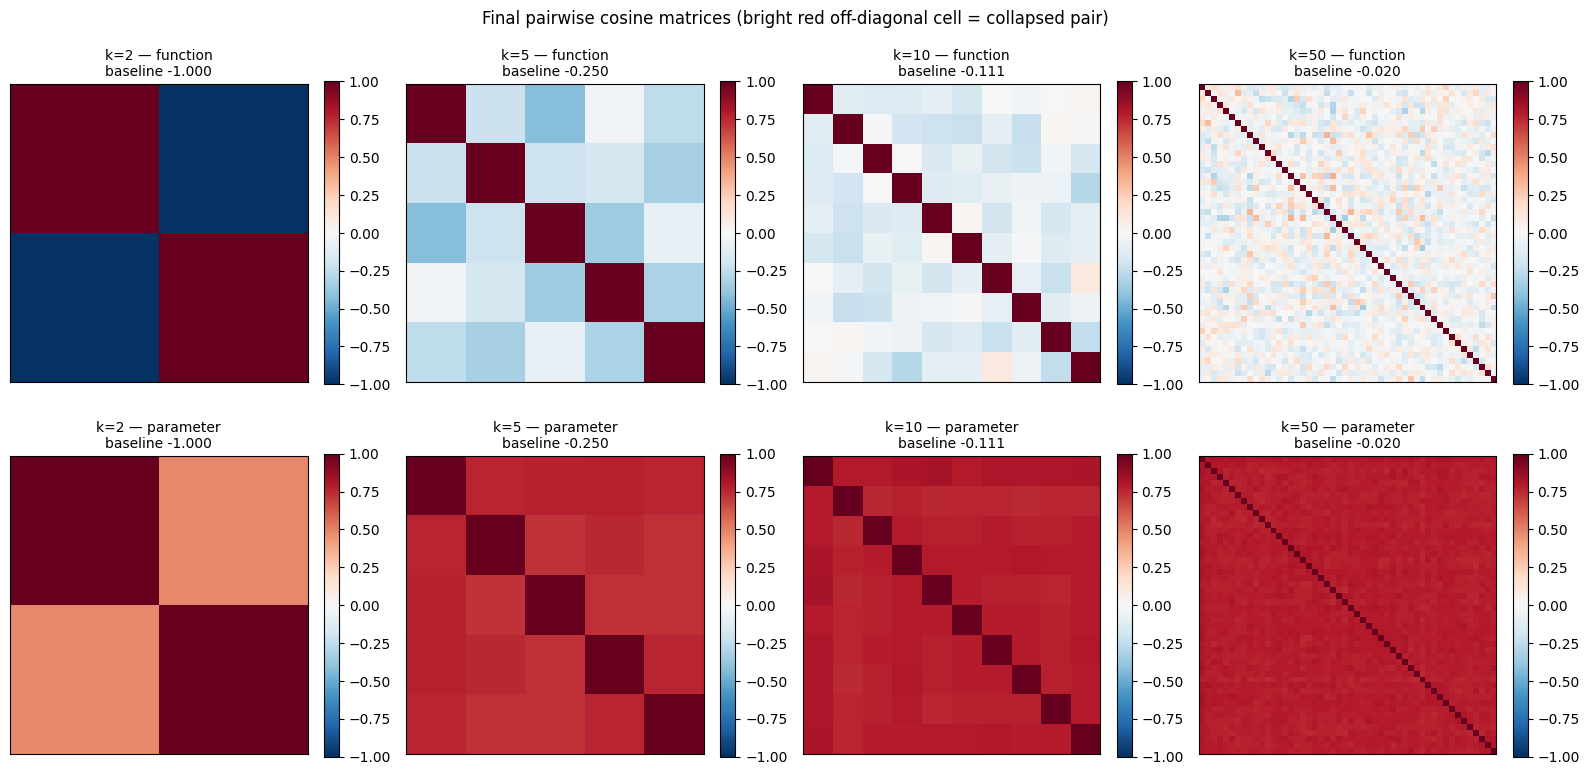

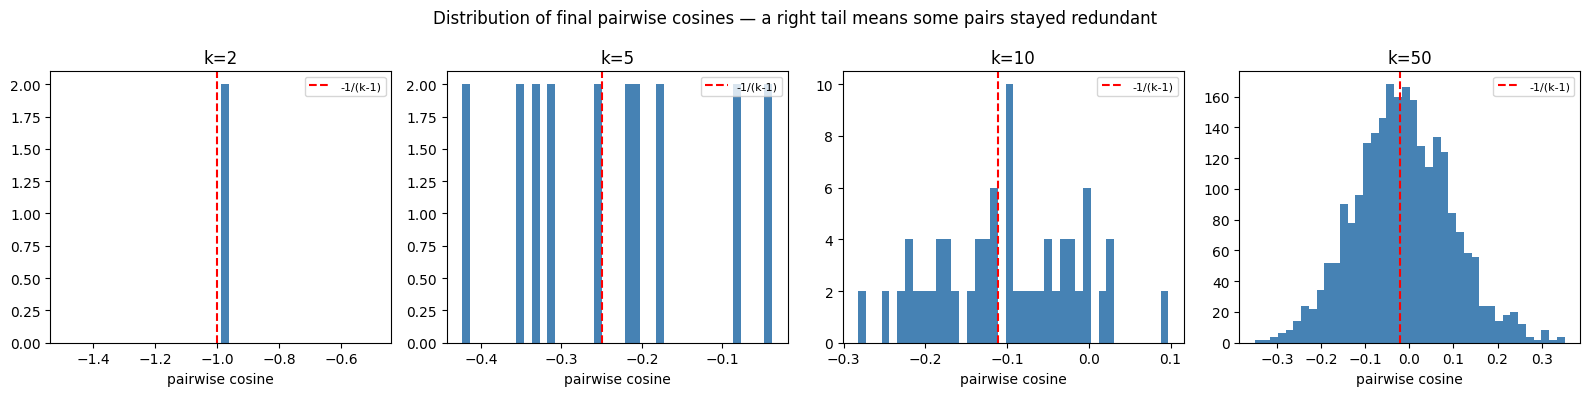

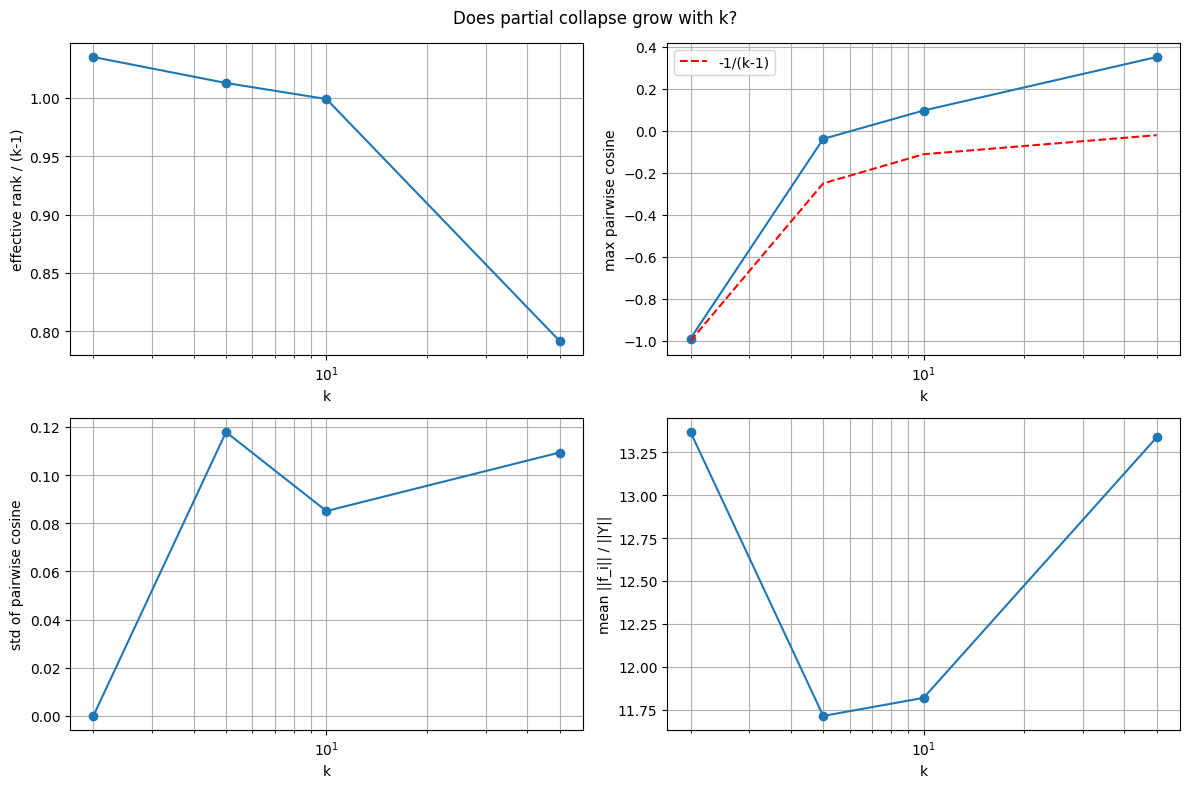

In [7]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ============================================================
# 0. Configuration
# ============================================================

SEED = 42

N = 512
INPUT_DIM = 10
OUTPUT_DIM = 10
HIDDEN_DIM = 128

K_LIST = [2, 5, 10, 50]

INIT_MODE = "near_identical"      # "independent" | "near_identical"
NOISE_STD = 1e-3               # only used for near_identical

EPOCHS = 500
LBFGS_MAX_ITER = 4
LBFGS_HISTORY = 50
LBFGS_LR = 1.0
LINE_SEARCH = "strong_wolfe"

TOL_GRAD = 0.0
TOL_CHANGE = 0.0

USE_DOUBLE = True

# A pair counts as "redundant" if its cosine sits well above
# the symmetric-simplex baseline of -1/(k-1).
COLLAPSE_MARGIN = 0.5

DTYPE = torch.float64 if USE_DOUBLE else torch.float32

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device, "| dtype:", DTYPE)


# ============================================================
# 1. Reproducibility
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ============================================================
# 2. Random memorization dataset
# ============================================================

X = torch.randn(N, INPUT_DIM, device=device, dtype=DTYPE)
Y = torch.randn(N, OUTPUT_DIM, device=device, dtype=DTYPE)


# ============================================================
# 3. Vectorized k-branch model
# ============================================================
#
# k separate 2-layer MLPs, batched with bmm so that k=50
# costs one kernel launch instead of fifty. Each branch is
# EXACTLY the same architecture as the original MLP(128).
#
# Params are stored as (k, ...) tensors, which also makes the
# per-branch parameter matrix trivial to extract.
#

class KBranchMLP(nn.Module):

    def __init__(
        self,
        k,
        in_dim=INPUT_DIM,
        hidden=HIDDEN_DIM,
        out_dim=OUTPUT_DIM
    ):

        super().__init__()

        self.k = k

        self.W1 = nn.Parameter(
            torch.empty(k, in_dim, hidden)
        )
        self.b1 = nn.Parameter(
            torch.zeros(k, 1, hidden)
        )
        self.W2 = nn.Parameter(
            torch.empty(k, hidden, out_dim)
        )
        self.b2 = nn.Parameter(
            torch.zeros(k, 1, out_dim)
        )

        self.reset_parameters()

    @torch.no_grad()
    def reset_parameters(self):

        # kaiming normal, fan_in mode, relu gain
        self.W1.normal_(
            0.0,
            math.sqrt(2.0 / self.W1.shape[1])
        )
        self.W2.normal_(
            0.0,
            math.sqrt(2.0 / self.W2.shape[1])
        )

        self.b1.zero_()
        self.b2.zero_()

    @torch.no_grad()
    def make_near_identical(self, noise_std):
        """
        Branch 0 stays as-is; every other branch is
        branch 0 + gaussian noise.
        """

        for p in [self.W1, self.b1, self.W2, self.b2]:

            base = p[0:1].clone()

            noise = noise_std * torch.randn_like(p)
            noise[0].zero_()

            p.copy_(base + noise)

    def branch_outputs(self, x):
        """
        returns (k, N, out_dim)
        """

        xb = x.unsqueeze(0).expand(self.k, -1, -1)

        h = torch.baddbmm(self.b1, xb, self.W1)
        h = torch.relu(h)

        return torch.baddbmm(self.b2, h, self.W2)

    def forward(self, x):

        f = self.branch_outputs(x)

        return f.mean(dim=0), f

    @torch.no_grad()
    def branch_param_matrix(self):
        """
        returns (k, P) — one flattened parameter vector
        per branch.
        """

        return torch.cat(
            [
                self.W1.reshape(self.k, -1),
                self.b1.reshape(self.k, -1),
                self.W2.reshape(self.k, -1),
                self.b2.reshape(self.k, -1),
            ],
            dim=1
        )


# ============================================================
# 4. Diversity metrics
# ============================================================

def normalized_gram(M, eps=1e-12):
    """
    M: (k, D)  ->  (k, k) cosine similarity matrix
    """

    Mn = M / (M.norm(dim=1, keepdim=True) + eps)

    return Mn @ Mn.t()


def offdiag(G):

    k = G.shape[0]

    mask = ~torch.eye(
        k,
        dtype=torch.bool,
        device=G.device
    )

    return G[mask]


def effective_rank(G, eps=1e-12):
    """
    Entropy-based effective rank of a PSD matrix.

    For k branches spread as a perfect symmetric simplex
    (every off-diagonal cosine = -1/(k-1)) this equals
    exactly k-1. Any partial collapse pushes it below.
    """

    ev = torch.linalg.eigvalsh(G)
    ev = torch.clamp(ev, min=0.0)

    total = ev.sum()

    if total <= eps:
        return 0.0

    p = ev / total
    p = p[p > eps]

    entropy = -(p * p.log()).sum()

    return entropy.exp().item()


@torch.no_grad()
def diversity_stats(model, X, Y):

    k = model.k

    f = model.branch_outputs(X)          # (k, N, d)
    F = f.reshape(k, -1)                 # (k, N*d)

    Gf = normalized_gram(F)
    Gp = normalized_gram(model.branch_param_matrix())

    off_f = offdiag(Gf)
    off_p = offdiag(Gp)

    baseline = -1.0 / (k - 1) if k > 1 else 0.0

    # how many pairs sit clearly above the simplex baseline
    n_collapsed = (
        off_f > (baseline + COLLAPSE_MARGIN)
    ).sum().item() / 2.0

    norm_ratio = (
        F.norm(dim=1).mean() / (Y.reshape(-1).norm() + 1e-12)
    ).item()

    return {
        "func_cos_mean": off_f.mean().item(),
        "func_cos_std": off_f.std().item(),
        "func_cos_max": off_f.max().item(),
        "param_cos_mean": off_p.mean().item(),
        "param_cos_max": off_p.max().item(),
        "eff_rank": effective_rank(Gf),
        "eff_rank_ratio": effective_rank(Gf) / max(k - 1, 1),
        "n_collapsed_pairs": n_collapsed,
        "norm_ratio": norm_ratio,
        "baseline": baseline,
        "Gf": Gf.cpu().numpy(),
        "Gp": Gp.cpu().numpy(),
    }


# ============================================================
# 5. Training
# ============================================================

def make_lbfgs(params):

    return torch.optim.LBFGS(
        params,
        lr=LBFGS_LR,
        max_iter=LBFGS_MAX_ITER,
        history_size=LBFGS_HISTORY,
        line_search_fn=LINE_SEARCH,
        tolerance_grad=TOL_GRAD,
        tolerance_change=TOL_CHANGE,
    )


def train_k_branch(
    k,
    epochs=EPOCHS,
    init_mode=INIT_MODE,
    noise_std=NOISE_STD,
    seed=SEED
):

    set_seed(seed)

    model = KBranchMLP(k).to(device=device, dtype=DTYPE)

    if init_mode == "near_identical":
        model.make_near_identical(noise_std)

    optimizer = make_lbfgs(model.parameters())

    loss_fn = nn.MSELoss()

    def closure():

        optimizer.zero_grad(set_to_none=True)

        ensemble, _ = model(X)

        loss = loss_fn(ensemble, Y)
        loss.backward()

        return loss

    history = {
        key: []
        for key in [
            "loss",
            "func_cos_mean",
            "func_cos_std",
            "func_cos_max",
            "param_cos_mean",
            "param_cos_max",
            "eff_rank",
            "eff_rank_ratio",
            "n_collapsed_pairs",
            "norm_ratio",
        ]
    }

    for epoch in range(epochs):

        optimizer.step(closure)

        with torch.no_grad():
            ensemble, _ = model(X)
            loss = loss_fn(ensemble, Y).item()

        if not math.isfinite(loss):
            print(f"  [warn] non-finite loss at step {epoch}")
            break

        stats = diversity_stats(model, X, Y)

        history["loss"].append(loss)

        for key in history:
            if key != "loss":
                history[key].append(stats[key])

    final_stats = diversity_stats(model, X, Y)

    return model, history, final_stats


# ============================================================
# 6. Run the sweep
# ============================================================

results = {}

for k in K_LIST:

    print("\n==============================")
    print(f"k = {k}  ({INIT_MODE} init)")
    print("==============================")

    model, history, final_stats = train_k_branch(k)

    results[k] = {
        "model": model,
        "history": history,
        "final": final_stats,
    }

    print(
        f"  final loss      = {history['loss'][-1]:.4e}\n"
        f"  mean pair cos   = {final_stats['func_cos_mean']:+.5f}"
        f"   (simplex baseline "
        f"{final_stats['baseline']:+.5f})\n"
        f"  std  pair cos   = {final_stats['func_cos_std']:.5f}\n"
        f"  max  pair cos   = {final_stats['func_cos_max']:+.5f}\n"
        f"  eff rank        = {final_stats['eff_rank']:.3f} / "
        f"{k - 1}  "
        f"(ratio {final_stats['eff_rank_ratio']:.4f})\n"
        f"  collapsed pairs = "
        f"{final_stats['n_collapsed_pairs']:.0f} / "
        f"{k * (k - 1) // 2}\n"
        f"  ||f||/||Y||     = {final_stats['norm_ratio']:.3f}"
    )


# ============================================================
# 7. Summary table
# ============================================================

print("\n\n============================================")
print("SUMMARY")
print("============================================")
print(
    f"{'k':>4} {'loss':>11} {'mean_cos':>10} "
    f"{'-1/(k-1)':>10} {'std':>8} {'max':>8} "
    f"{'effrank':>9} {'/(k-1)':>8}"
)

for k in K_LIST:

    s = results[k]["final"]
    h = results[k]["history"]

    print(
        f"{k:>4} {h['loss'][-1]:>11.3e} "
        f"{s['func_cos_mean']:>+10.5f} "
        f"{s['baseline']:>+10.5f} "
        f"{s['func_cos_std']:>8.4f} "
        f"{s['func_cos_max']:>+8.4f} "
        f"{s['eff_rank']:>9.3f} "
        f"{s['eff_rank_ratio']:>8.4f}"
    )


# ============================================================
# 8. Plot 1: loss vs k
# ============================================================

plt.figure(figsize=(10, 6))

for k in K_LIST:
    plt.plot(
        results[k]["history"]["loss"],
        label=f"k={k}"
    )

plt.yscale("log")
plt.xlabel("LBFGS step")
plt.ylabel("Ensemble training MSE")
plt.title("Joint k-branch memorization: does more k help?")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 9. Plot 2: mean pairwise cosine vs simplex baseline
# ============================================================

plt.figure(figsize=(10, 6))

for i, k in enumerate(K_LIST):

    color = f"C{i}"

    plt.plot(
        results[k]["history"]["func_cos_mean"],
        color=color,
        label=f"k={k}"
    )

    plt.axhline(
        -1.0 / (k - 1),
        color=color,
        linestyle="--",
        alpha=0.5,
        linewidth=1
    )

plt.xlabel("LBFGS step")
plt.ylabel("Mean pairwise function cosine")
plt.title(
    "Mean pairwise cosine (solid) vs -1/(k-1) simplex "
    "baseline (dashed)"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Plot 3: effective rank ratio
#     THE partial-collapse indicator
# ============================================================

plt.figure(figsize=(10, 6))

for k in K_LIST:
    plt.plot(
        results[k]["history"]["eff_rank_ratio"],
        label=f"k={k}"
    )

plt.axhline(
    1.0,
    color="k",
    linestyle="--",
    alpha=0.6,
    label="full spread (k-1)"
)

plt.xlabel("LBFGS step")
plt.ylabel("effective rank / (k-1)")
plt.title(
    "Partial collapse indicator — "
    "1.0 means all k branches are fully distinct"
)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Plot 4: spread of pairwise cosines
# ============================================================

plt.figure(figsize=(10, 6))

for k in K_LIST:

    h = results[k]["history"]

    plt.plot(
        h["func_cos_std"],
        label=f"k={k}"
    )

plt.yscale("log")
plt.xlabel("LBFGS step")
plt.ylabel("std of off-diagonal cosines")
plt.title(
    "Heterogeneity of the pairwise structure "
    "(0 = perfectly symmetric simplex)"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 12. Plot 5: final pairwise cosine matrices
# ============================================================

n = len(K_LIST)

fig, axes = plt.subplots(
    2,
    n,
    figsize=(4 * n, 8)
)

if n == 1:
    axes = axes.reshape(2, 1)

for j, k in enumerate(K_LIST):

    s = results[k]["final"]
    b = s["baseline"]

    for row, key, name in [
        (0, "Gf", "function"),
        (1, "Gp", "parameter"),
    ]:

        ax = axes[row, j]

        im = ax.imshow(
            s[key],
            cmap="RdBu_r",
            vmin=-1,
            vmax=1
        )

        ax.set_title(
            f"k={k} — {name}\n"
            f"baseline {b:+.3f}",
            fontsize=10
        )

        ax.set_xticks([])
        ax.set_yticks([])

        fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(
    "Final pairwise cosine matrices "
    "(bright red off-diagonal cell = collapsed pair)"
)
plt.tight_layout()
plt.show()


# ============================================================
# 13. Plot 6: histogram of final off-diagonal cosines
# ============================================================

fig, axes = plt.subplots(
    1,
    n,
    figsize=(4 * n, 4)
)

if n == 1:
    axes = [axes]

for ax, k in zip(axes, K_LIST):

    G = results[k]["final"]["Gf"]

    mask = ~np.eye(k, dtype=bool)
    vals = G[mask]

    ax.hist(vals, bins=40, color="steelblue")

    ax.axvline(
        -1.0 / (k - 1),
        color="red",
        linestyle="--",
        label="-1/(k-1)"
    )

    ax.set_title(f"k={k}")
    ax.set_xlabel("pairwise cosine")
    ax.legend(fontsize=8)

plt.suptitle(
    "Distribution of final pairwise cosines — "
    "a right tail means some pairs stayed redundant"
)
plt.tight_layout()
plt.show()


# ============================================================
# 14. Plot 7: scaling of collapse with k
# ============================================================

ks = np.array(K_LIST, dtype=float)

eff_ratio = np.array([
    results[k]["final"]["eff_rank_ratio"] for k in K_LIST
])

cos_max = np.array([
    results[k]["final"]["func_cos_max"] for k in K_LIST
])

cos_std = np.array([
    results[k]["final"]["func_cos_std"] for k in K_LIST
])

norm_ratio = np.array([
    results[k]["final"]["norm_ratio"] for k in K_LIST
])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, y, name in [
    (axes[0, 0], eff_ratio, "effective rank / (k-1)"),
    (axes[0, 1], cos_max, "max pairwise cosine"),
    (axes[1, 0], cos_std, "std of pairwise cosine"),
    (axes[1, 1], norm_ratio, "mean ||f_i|| / ||Y||"),
]:

    ax.semilogx(ks, y, marker="o")
    ax.set_xlabel("k")
    ax.set_ylabel(name)
    ax.grid(True, which="both")

axes[0, 1].semilogx(
    ks,
    -1.0 / (ks - 1),
    linestyle="--",
    color="red",
    label="-1/(k-1)"
)
axes[0, 1].legend()

plt.suptitle("Does partial collapse grow with k?")
plt.tight_layout()
plt.show()